# EV Car Price Prediction in Vietnam — Comprehensive Project Report

## 1. Project Overview \& Objectives

### Problem Statement
The Vietnamese electric vehicle (EV) market is rapidly growing, driven primarily by VinFast's domestic production. However, there is no reliable tool for predicting second-hand EV prices in Vietnam. This project aims to build a machine learning pipeline that:

1. **Collects** EV listing data from 4 Vietnamese car marketplace websites
2. **Cleans and harmonizes** heterogeneous data sources into a unified schema
3. **Extracts structured features** from unstructured text using a local LLM
4. **Engineers features** optimized for 4 different regression models
5. **Trains and benchmarks** Linear Regression (Ridge), SVR, Random Forest, and XGBoost

### Technical Stack
- **Language:** Python 3.12+ (managed with `uv`)
- **Scraping:** Scrapy (chotot), BeautifulSoup4 + Requests (otodien, xevinfastluot), pre-scraped CSV (bonbanh)
- **LLM Extraction:** Ollama local (qwen2.5:3b), OpenAI GPT-5-Nano (batch)
- **ML:** scikit-learn, XGBoost
- **Visualization:** matplotlib (LaTeX rendering via MiKTeX), seaborn


In [1]:
import os, sys, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".")
sys.path.insert(0, str(ROOT))

from src.viz.style import (
    apply_style, latex_safe, add_bar_labels,
    PALETTE, COLOR_PRIMARY, COLOR_ACCENT, COLOR_GOOD, COLOR_BAD,
    TABLE_HEADER, TABLE_ROW_ALT,
    FIGSIZE_SINGLE, FIGSIZE_WIDE, FIGSIZE_TALL, FIGSIZE_TABLE,
)
apply_style()

DATA_RAW = ROOT / "data" / "raw"
DATA_INTERIM = ROOT / "data" / "interim"
DATA_PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports" / "model_benchmark"

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(f"Project root: {ROOT}")
print(f"Raw data:     {list(DATA_RAW.glob('*'))}")


Project root: C:\Users\dduya\Work\project\ev_car
Raw data:     [WindowsPath('C:/Users/dduya/Work/project/ev_car/data/raw/bonbanh.csv'), WindowsPath('C:/Users/dduya/Work/project/ev_car/data/raw/chotot'), WindowsPath('C:/Users/dduya/Work/project/ev_car/data/raw/data_xe_dien_web_otodien.csv'), WindowsPath('C:/Users/dduya/Work/project/ev_car/data/raw/xevinfastluot_full.csv')]


In [2]:
# Project directory structure
for root_dir, dirs, files in os.walk(ROOT):
    # Skip hidden dirs, __pycache__, .git, node_modules
    dirs[:] = [d for d in dirs if not d.startswith('.') and d != '__pycache__' and d != 'node_modules' and d != '.scrapy']
    level = root_dir.replace(str(ROOT), "").count(os.sep)
    indent = " " * 2 * level
    basename = os.path.basename(root_dir)
    if level == 0:
        print(f"ev_car/")
    else:
        print(f"{indent}{basename}/")
    sub_indent = " " * 2 * (level + 1)
    for f in sorted(files):
        if not f.startswith('.'):
            print(f"{sub_indent}{f}")


ev_car/
  README.md
  pyproject.toml
  uv.lock
  auxil/
    presentation.aux
    presentation.log
    presentation.nav
    presentation.out
    presentation.snm
    presentation.toc
  configs/
    local_llm_config.yaml
  data/
    interim/
      ev_cleaned_rule_based.csv
      ev_eda_ready.csv
      ev_extracted_gpt5nano.csv
      ev_extracted_qwen2.5_3b.csv
      ev_specs_lookup.csv
      feature_dictionary.json
      merged_raw_listings.csv
      checkpoints/
        ev_phase1_cleaned.csv
    processed/
      X_test.csv
      X_test_scaled.csv
      X_train.csv
      X_train_scaled.csv
      feature_names.csv
      sample_weights_train.csv
      scaler.joblib
      y_test.csv
      y_test_log.csv
      y_train.csv
      y_train_log.csv
    raw/
      bonbanh.csv
      data_xe_dien_web_otodien.csv
      xevinfastluot_full.csv
      chotot/
        cars.json
  docs/
    research/
      IEEEtran.cls
      New_IEEEtran_how-to.pdf
      New_IEEEtran_how-to.tex
      bare_jrnl_new_sample4.

---
## 2. Data Collection (Web Scraping)

Four Vietnamese car marketplace websites were scraped using different methods:

| Source | Library | Method | Pagination | Records |
|--------|---------|--------|------------|---------|
| **chotot.com** | Scrapy | Parse `__NEXT_DATA__` JSON from rendered pages | `?page=N` query param | ~1,666 |
| **otodien.vn** | BeautifulSoup + Requests | Parse HTML listing pages + detail pages | `?page=1..42` | ~728 |
| **xevinfastluot.com** | BeautifulSoup + Requests | Sitemap XML discovery + WP REST API for dates | Sitemap-based | ~279 |
| **bonbanh.com** | Pre-scraped CSV | Direct CSV load (19 standard fields) | N/A | ~7,466 raw (~1,493 EV) |

### Scraper Details

- **chotot.com** uses a Scrapy spider (`scripts/chotot/chotot/spiders/cars.py`) that extracts deeply nested JSON from Next.js server-side rendered pages. The spider flattens 150+ fields from the `ad_params` structure into flat columns.

- **otodien.vn** (`scripts/otodien/scaper_otodien.py`) is the richest source — it captures 35 fields including EV-specific specs: battery capacity (kWh), range (km), charging times, power output (hp), and 0-100 km/h acceleration. It also parses relative dates like ``2 tieng'' into absolute timestamps.

- **xevinfastluot.com** (`scripts/VFluotScraper.py`) specializes in used VinFast vehicles. It discovers URLs via sitemap XML parsing and retrieves post dates from the WordPress REST API (`/wp-json/wp/v2/san-pham`).

- **bonbanh.com** data arrives as a pre-formatted CSV with the standard 19-field schema used across Vietnamese car marketplaces.


In [3]:
# --- Load each raw data source ---
bonbanh = pd.read_csv(DATA_RAW / "bonbanh.csv")
otodien = pd.read_csv(DATA_RAW / "data_xe_dien_web_otodien.csv")
xevinfastluot = pd.read_csv(DATA_RAW / "xevinfastluot_full.csv")

with open(DATA_RAW / "chotot" / "cars.json", "r", encoding="utf-8") as f:
    chotot_raw = json.load(f)
chotot = pd.json_normalize(chotot_raw)

print("=" * 70)
print("RAW DATA SOURCE SUMMARY")
print("=" * 70)
sources = {
    "bonbanh.com": bonbanh,
    "otodien.vn": otodien,
    "xevinfastluot.com": xevinfastluot,
    "chotot.com": chotot,
}
for name, df in sources.items():
    print(f"\n{name}:")
    print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"  Columns: {list(df.columns[:10])}{'...' if len(df.columns) > 10 else ''}")
    print(f"  Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

total = sum(df.shape[0] for df in sources.values())
print(f"\nTotal raw records: {total:,}")


RAW DATA SOURCE SUMMARY

bonbanh.com:
  Shape: 1,493 rows x 19 columns
  Columns: ['Ngày đăng', 'Tên xe', 'Giá', 'Tên người bán', 'Địa chỉ', 'Năm sản xuất', 'Tình trạng', 'Số Km đã đi', 'Xuất xứ', 'Kiểu dáng']...
  Memory: 3.7 MB

otodien.vn:
  Shape: 728 rows x 34 columns
  Columns: ['ID', 'Tên', 'Tiền (VNĐ)', 'Vị trí', 'Ngày đăng', 'Người dùng', 'Sao', 'Đã bán', 'Đang bán', 'Thông tin mô tả']...
  Memory: 2.2 MB

xevinfastluot.com:
  Shape: 279 rows x 19 columns
  Columns: ['Ngày đăng', 'Tên xe', 'Giá', 'Tên người bán', 'Địa chỉ', 'Năm sản xuất', 'Tình trạng', 'Số Km đã đi', 'Xuất xứ', 'Kiểu dáng']...
  Memory: 0.5 MB

chotot.com:
  Shape: 1,666 rows x 186 columns
  Columns: ['url', 'exact_date_posted', 'parameters', 'params', 'ad.account_id', 'ad.account_name', 'ad.account_oid', 'ad.ad_features', 'ad.ad_id', 'ad.ad_labels']...
  Memory: 19.8 MB

Total raw records: 4,166


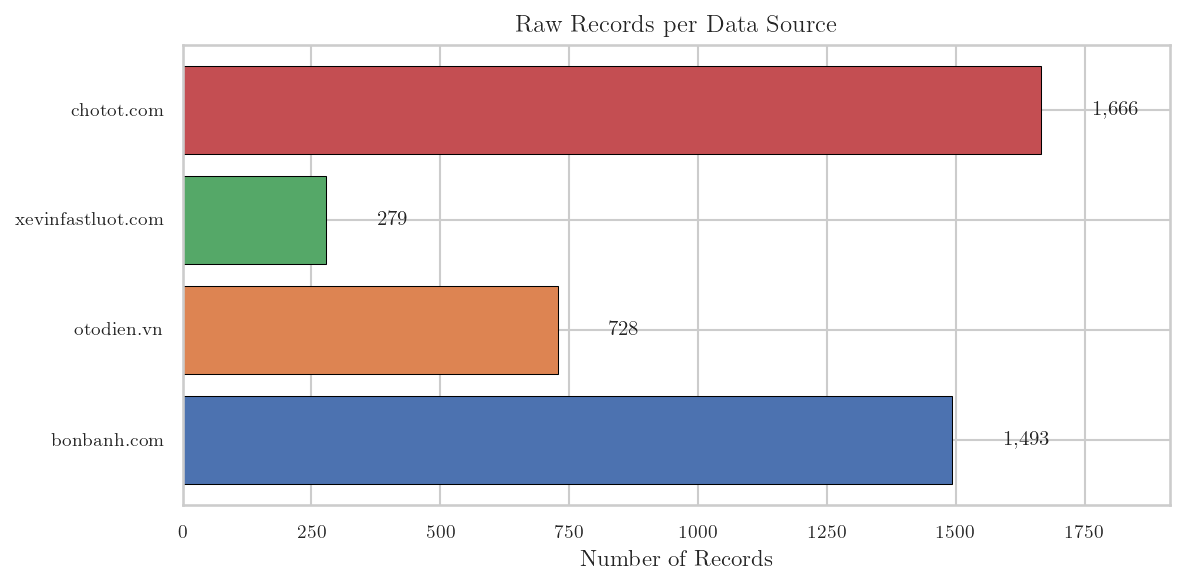

In [4]:
# --- Record count per source (bar chart) ---
fig, ax = plt.subplots(figsize=(8, 4))
names = list(sources.keys())
counts = [df.shape[0] for df in sources.values()]
colors = PALETTE
bars = ax.barh(names, counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va="center", fontsize=10)
ax.set_xlabel(r"Number of Records")
ax.set_title(r"Raw Records per Data Source")
ax.set_xlim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()


In [5]:
# --- Column coverage comparison across sources ---
# Show what each source uniquely offers
print("=" * 70)
print("UNIQUE COLUMNS PER SOURCE (not shared by all 4)")
print("=" * 70)

# Core schema columns (shared by bonbanh and xevinfastluot)
core_cols_vn = [
    "Ngày đăng", "Tên xe", "Giá", "Tên người bán", "Địa chỉ",
    "Năm sản xuất", "Tình trạng", "Số Km đã đi", "Xuất xứ",
    "Kiểu dáng", "Hộp số", "Động cơ", "Màu ngoại thất", "Màu nội thất",
    "Số chỗ ngồi", "Số cửa", "Dẫn động", "Mô tả", "Link"
]
print(f"\nCore schema (19 fields, used by bonbanh + xevinfastluot): {len(core_cols_vn)} cols")

# Otodien's unique EV-specific columns
otodien_ev_cols = [c for c in otodien.columns if c not in core_cols_vn and c not in [
    "ID", "Tên", "Tiền (VNĐ)", "Vị trí", "Người dùng", "Sao", "Đã bán", "Đang bán"
]]
print(f"\nOtodien.vn EV-specific columns ({len(otodien_ev_cols)} unique):")
for c in otodien_ev_cols:
    non_null_pct = otodien[c].notna().mean() * 100 if c in otodien.columns else 0
    print(f"  - {c} ({non_null_pct:.0f}% non-null)")

# Chotot's unique columns
print(f"\nChotot.com total columns: {len(chotot.columns)} (150+ from nested JSON)")
chotot_interesting = [c for c in chotot.columns if "ad_params" in c and "value" in c]
print(f"  ad_params value fields: {len(chotot_interesting)}")
for c in sorted(chotot_interesting)[:15]:
    print(f"  - {c}")
print(f"  ... and {len(chotot_interesting) - 15} more")


UNIQUE COLUMNS PER SOURCE (not shared by all 4)

Core schema (19 fields, used by bonbanh + xevinfastluot): 19 cols

Otodien.vn EV-specific columns (23 unique):
  - Thông tin mô tả (100% non-null)
  - Tính năng nổi bật (100% non-null)
  - Tính năng khác (100% non-null)
  - Màu bên ngoài (99% non-null)
  - Chiều dài(mm) (100% non-null)
  - Chiều dài cơ sở(mm) (100% non-null)
  - Chiều rộng(mm) (100% non-null)
  - khoảng sáng gầm(mm) (99% non-null)
  - Trọng lượng bản thân (kg) (89% non-null)
  - Trọng lượng toàn tải (kg) (88% non-null)
  - Dung tích khoang hành lý (lít) (71% non-null)
  - Dung tích khoang hành lý khi gập ghế sau (lít) (64% non-null)
  - Công suất tốt đa(hp) (100% non-null)
  - Tốc độ tối đa (km/h) (99% non-null)
  - 0-100(s) (98% non-null)
  - Tầm hoạt động (km) (100% non-null)
  - Dung lượng pin (kWh) (100% non-null)
  - Chi phí sạc đầy (VNĐ) (100% non-null)
  - Chi phí sạc hàng tháng (VNĐ) (99% non-null)
  - Sạc chậm (giờ) (100% non-null)
  - Sạc tiêu chuẩn (giờ) (100%

In [6]:
# --- Otodien EV-spec columns: the lost treasure ---
print("=" * 70)
print("OTODIEN EV-SPECIFIC DATA (DROPPED DURING HARMONIZATION)")
print("=" * 70)
ev_spec_cols = [
    "Dung lượng pin (kWh)", "Tầm hoạt động (km)", "Công suất tốt đa(hp)",
    "Tốc độ tối đa (km/h)", "0-100(s)", "Chi phí sạc đầy (VNĐ)",
    "Chi phí sạc hàng tháng (VNĐ)", "Sạc chậm (giờ)", "Sạc tiêu chuẩn (giờ)",
    "Chiều dài(mm)", "Chiều rộng(mm)", "khoảng sáng gầm(mm)",
    "Trọng lượng bản thân (kg)", "Dung tích khoang hành lý (lít)"
]
for c in ev_spec_cols:
    if c in otodien.columns:
        non_null = otodien[c].notna().sum()
        pct = non_null / len(otodien) * 100
        sample_vals = otodien[c].dropna().head(3).tolist()
        print(f"  {c:40s}: {non_null:3d}/{len(otodien)} ({pct:.0f}%) — e.g. {sample_vals}")
    else:
        print(f"  {c:40s}: [column not found]")

print(f"\nThese {len(ev_spec_cols)} EV-specific columns exist ONLY in otodien.vn ({len(otodien)} records)")
print("and are DISCARDED during harmonization to the 20-column unified schema.")
print("This is the single largest information loss in the pipeline.")


OTODIEN EV-SPECIFIC DATA (DROPPED DURING HARMONIZATION)
  Dung lượng pin (kWh)                    : 725/728 (100%) — e.g. [82.0, 60.1, 82.0]
  Tầm hoạt động (km)                      : 725/728 (100%) — e.g. [420.0, 450.0, 400.0]
  Công suất tốt đa(hp)                    : 725/728 (100%) — e.g. [349.0, 204.0, 402.0]
  Tốc độ tối đa (km/h)                    : 718/728 (99%) — e.g. [200.0, 175.0, 200.0]
  0-100(s)                                : 716/728 (98%) — e.g. [6.5, 9.5, 5.5]
  Chi phí sạc đầy (VNĐ)                   : 725/728 (100%) — e.g. [156000.0, 132000.0, 156000.0]
  Chi phí sạc hàng tháng (VNĐ)            : 724/728 (99%) — e.g. [585000.0, 465000.0, 585000.0]
  Sạc chậm (giờ)                          : 725/728 (100%) — e.g. ['8-10', '18', '8-10']
  Sạc tiêu chuẩn (giờ)                    : 725/728 (100%) — e.g. [4.0, 7.0, 4.0]
  Chiều dài(mm)                           : 725/728 (100%) — e.g. [4750.0, 4740.0, 4750.0]
  Chiều rộng(mm)                          : 725/728 (100%) —

---
## 3. Data Harmonization

The harmonization step (`scripts/harmonize_datasets.py`, class `DataHarmonizer`) maps all 4 sources to a **20-column unified schema**. Each source has different column names and structures:

| Source | Mapping Strategy |
|--------|-----------------|
| **bonbanh** | Direct rename (already matches core schema) + add `Website` column |
| **xevinfastluot** | Direct rename + add `Website` |
| **otodien** | Map: `Ten` $\to$ `Ten xe`, `Tien (VND)` $\to$ `Gia`, etc. Auto-impute: `Ho so = So tu dong`, `Dong co = Dien` (100\% EV) |
| **chotot** | Flatten nested JSON: `ad.subject` $\to$ `Ten xe`, `ad\_params.mfdate.value` $\to$ `Nam san xuat`, etc. |

**Critical trade-off:** Forcing all sources to the lowest-common-denominator schema means otodien's 14 EV-specific columns (battery, range, charging, performance) are discarded. This is the single biggest information loss in the pipeline.


In [7]:
# --- Load merged dataset ---
merged = pd.read_csv(DATA_INTERIM / "merged_raw_listings.csv")
print(f"Merged dataset shape: {merged.shape[0]:,} rows x {merged.shape[1]} columns")
print(f"\nColumns ({merged.shape[1]}):")
for i, c in enumerate(merged.columns):
    print(f"  {i+1:2d}. {c}")

print(f"\nRecords per website:")
print(merged["Website"].value_counts().to_string())
print(f"\nTotal: {merged.shape[0]:,}")


Merged dataset shape: 4,166 rows x 20 columns

Columns (20):
   1. Ngày đăng
   2. Tên xe
   3. Giá
   4. Tên người bán
   5. Địa chỉ
   6. Năm sản xuất
   7. Tình trạng
   8. Số Km đã đi
   9. Xuất xứ
  10. Kiểu dáng
  11. Hộp số
  12. Động cơ
  13. Màu ngoại thất
  14. Màu nội thất
  15. Số chỗ ngồi
  16. Số cửa
  17. Dẫn động
  18. Mô tả
  19. Link
  20. Website

Records per website:
Website
chotot.com           1666
bonbanh.com          1493
otodien.vn            728
xevinfastluot.com     279

Total: 4,166


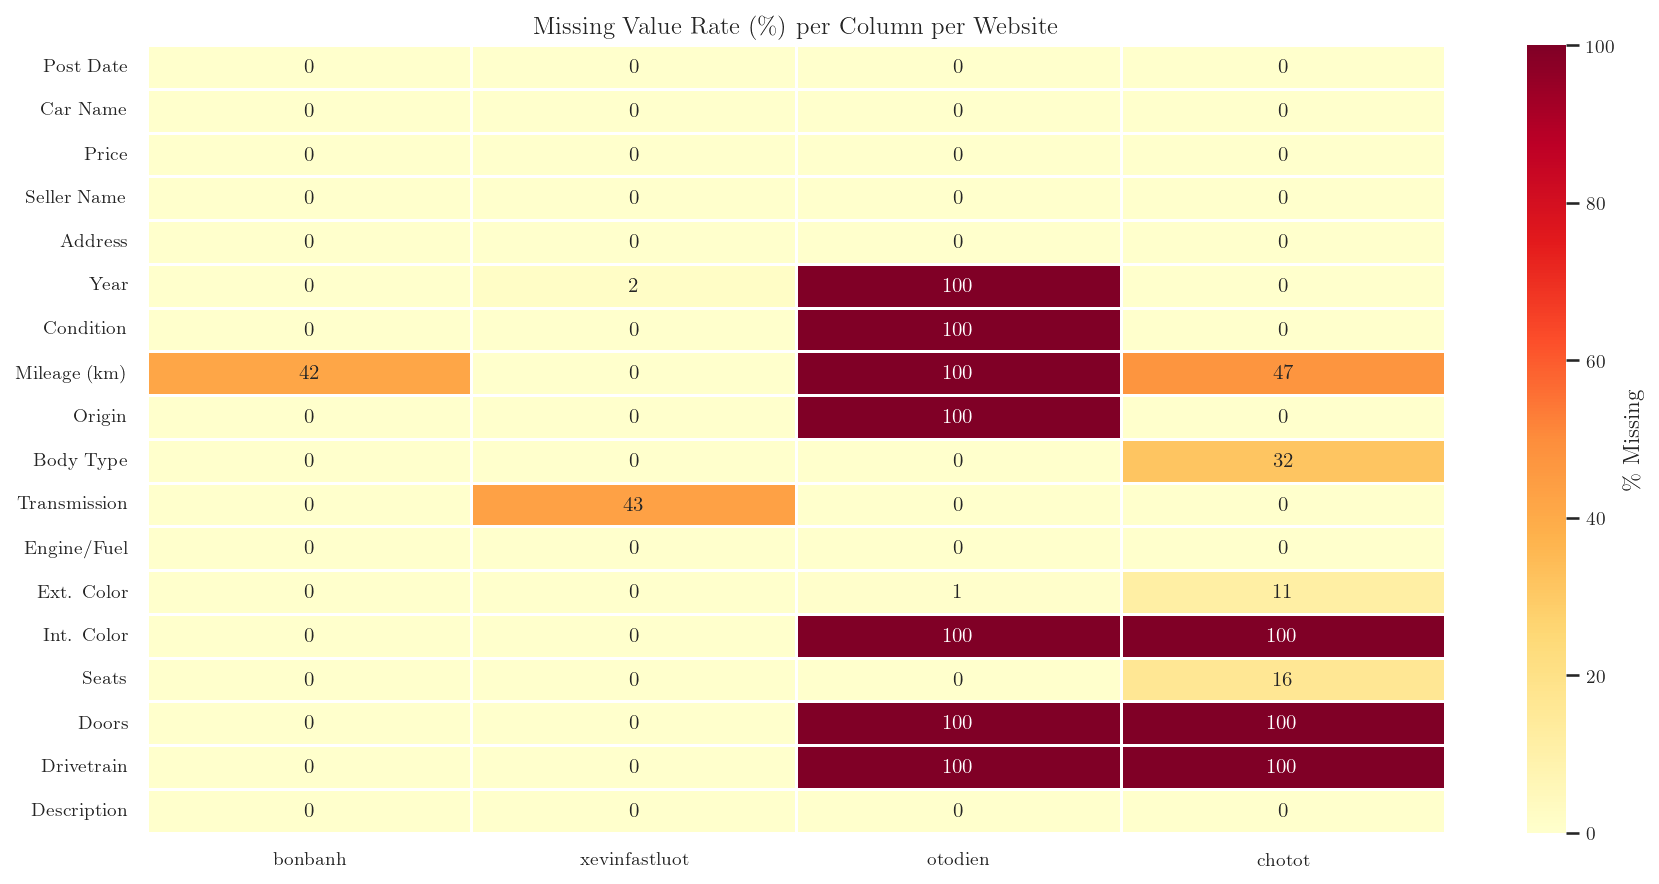

In [8]:
# --- Missing value rate per column per website ---
# Map Vietnamese column names to English for LaTeX-safe plotting
VN_TO_EN = {
    "Ngày đăng": "Post Date", "Tên xe": "Car Name", "Giá": "Price",
    "Tên người bán": "Seller Name", "Địa chỉ": "Address",
    "Năm sản xuất": "Year", "Tình trạng": "Condition",
    "Số Km đã đi": "Mileage (km)", "Xuất xứ": "Origin",
    "Kiểu dáng": "Body Type", "Hộp số": "Transmission",
    "Động cơ": "Engine/Fuel", "Màu ngoại thất": "Ext. Color",
    "Màu nội thất": "Int. Color", "Số chỗ ngồi": "Seats",
    "Số cửa": "Doors", "Dẫn động": "Drivetrain", "Mô tả": "Description",
}

fig, ax = plt.subplots(figsize=(12, 6))
websites = merged["Website"].unique()
cols_to_check = [c for c in merged.columns if c not in ["Website", "Link"]]
missing_matrix = pd.DataFrame(index=cols_to_check, columns=websites, dtype=float)

for w in websites:
    subset = merged[merged["Website"] == w]
    for c in cols_to_check:
        missing_matrix.loc[c, w] = subset[c].isna().mean() * 100

# Rename index to English
missing_matrix.index = [VN_TO_EN.get(c, c) for c in missing_matrix.index]
# Shorten website names for axis
missing_matrix.columns = [w.replace(".com", "").replace(".vn", "") for w in missing_matrix.columns]

sns.heatmap(missing_matrix.astype(float), annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=100, cbar_kws={"label": r"\% Missing"})
ax.set_title(r"Missing Value Rate (\%) per Column per Website")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


---
## 4. Rule-Based Cleaning

The cleaning script (`scripts/preprocess_rule_based.py`, class `DataPreprocessor`) performs:

1. **Text normalization** — Remove line breaks, carriage returns, tabs, multiple spaces from car names
2. **Vietnamese price parsing** — Convert strings like ``2.5 ty'' $\to$ 2,500,000,000 VND, ``500 trieu'' $\to$ 500,000,000 VND, ``26x trieu'' $\to$ 260,000,000 VND (obfuscated format)
3. **ICE vehicle filtering** — Remove gasoline/diesel cars: filter `Dong co` $\in$ \{`xang`, `dau`\} and model names containing `fadil`, `lux a`, `lux sa`, `president` (VinFast ICE models)
4. **Date standardization** — Convert mixed formats to `YYYY-MM-DD`
5. **Column cleanup** — Drop `Gia` (original string), `Dong co`, `Ho so`; create `Gia_VND` (parsed float)


In [9]:
# --- Load cleaned dataset ---
cleaned = pd.read_csv(DATA_INTERIM / "ev_cleaned_rule_based.csv")
print(f"After rule-based cleaning: {cleaned.shape[0]:,} rows x {cleaned.shape[1]} columns")
print(f"Records dropped from merged: {merged.shape[0] - cleaned.shape[0]:,} ({(merged.shape[0] - cleaned.shape[0]) / merged.shape[0] * 100:.1f}%)")
print(f"\nRecords per website after cleaning:")
if "Website" in cleaned.columns:
    print(cleaned["Website"].value_counts().to_string())
elif "website" in cleaned.columns:
    print(cleaned["website"].value_counts().to_string())

# Price column (may be Giá_VND or price_vnd)
price_col = [c for c in cleaned.columns if "vnd" in c.lower() or "giá" in c.lower() or "price" in c.lower()]
print(f"\nPrice column(s) found: {price_col}")
if price_col:
    pc = price_col[0]
    p = cleaned[pc].dropna()
    print(f"\nPrice distribution (VND):")
    print(f"  Count:  {p.count():,}")
    print(f"  Mean:   {p.mean():,.0f}")
    print(f"  Median: {p.median():,.0f}")
    print(f"  Std:    {p.std():,.0f}")
    print(f"  Min:    {p.min():,.0f}")
    print(f"  Max:    {p.max():,.0f}")


After rule-based cleaning: 3,992 rows x 18 columns
Records dropped from merged: 174 (4.2%)

Records per website after cleaning:
Website
chotot.com           1660
bonbanh.com          1493
otodien.vn            728
xevinfastluot.com     111

Price column(s) found: ['Giá_VND']

Price distribution (VND):
  Count:  3,990
  Mean:   2,789,441,383
  Median: 910,000,000
  Std:    3,726,188,062
  Min:    9,680,000
  Max:    72,900,000,000


C:\Users\dduya\AppData\Local\Temp\ipykernel_10944\1197956716.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_web, labels=[w.replace(".com", "").replace(".vn", "") for w in websites_clean],


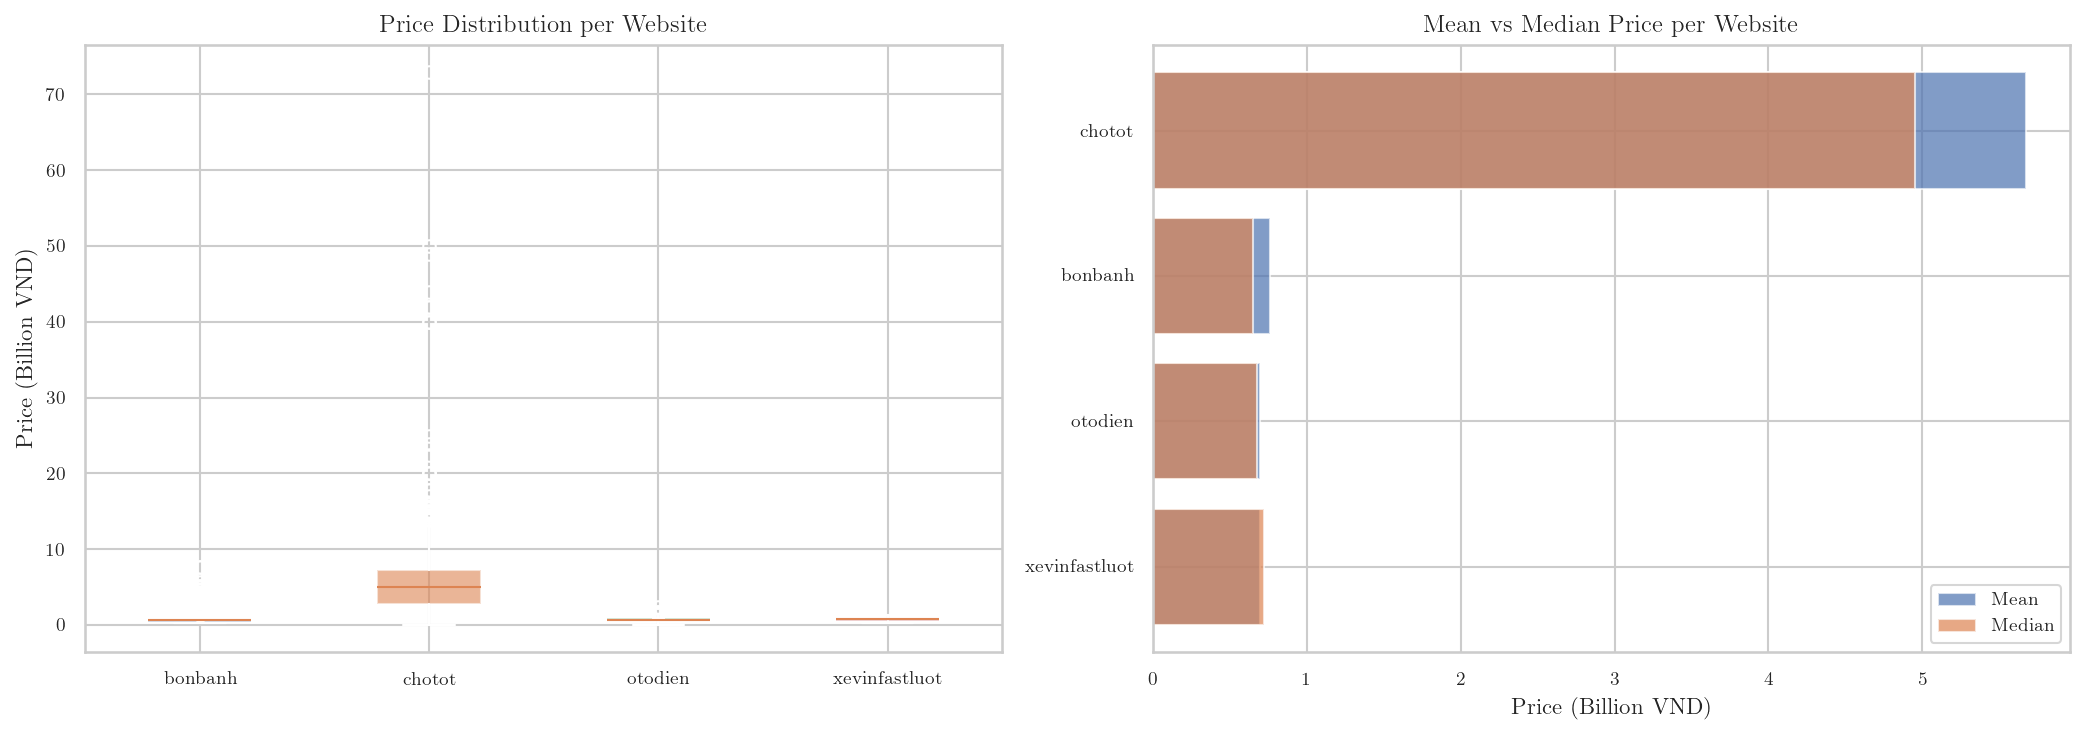


Per-website price statistics (Billion VND):
                   Count (raw)  Mean (B)  Median (B)  Std (B)  Min (B)  Max (B)
Website                                                                        
bonbanh.com               1493      0.76        0.65     0.72     0.19     7.61
chotot.com                1658      5.68        4.95     4.32     0.01    72.90
otodien.vn                 728      0.70        0.68     0.32     0.03     2.31
xevinfastluot.com          111      0.70        0.72     0.28     0.21     1.37


In [10]:
# --- Price distribution per website ---
price_col = [c for c in cleaned.columns if "vnd" in c.lower() or "price" in c.lower()]
web_col = "Website" if "Website" in cleaned.columns else "website"
if price_col:
    pc = price_col[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box plot per website
    websites_clean = sorted(cleaned[web_col].dropna().unique())
    data_by_web = [cleaned.loc[cleaned[web_col] == w, pc].dropna() / 1e9 for w in websites_clean]
    bp = axes[0].boxplot(data_by_web, labels=[w.replace(".com", "").replace(".vn", "") for w in websites_clean],
                         patch_artist=True, showfliers=True)
    colors_box = PALETTE
    for patch, color in zip(bp["boxes"], colors_box[:len(websites_clean)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[0].set_ylabel(r"Price (Billion VND)")
    axes[0].set_title(r"Price Distribution per Website")

    # Average price per website
    avg_prices = cleaned.groupby(web_col)[pc].agg(["mean", "median", "count"])
    avg_prices = avg_prices.sort_values("mean", ascending=True)
    y_pos = range(len(avg_prices))
    axes[1].barh(y_pos, avg_prices["mean"] / 1e9, color=COLOR_PRIMARY, alpha=0.7, label=r"Mean")
    axes[1].barh(y_pos, avg_prices["median"] / 1e9, color=COLOR_ACCENT, alpha=0.7, label=r"Median")
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([idx.replace(".com", "").replace(".vn", "") for idx in avg_prices.index])
    axes[1].set_xlabel(r"Price (Billion VND)")
    axes[1].set_title(r"Mean vs Median Price per Website")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\nPer-website price statistics (Billion VND):")
    stats_df = cleaned.groupby(web_col)[pc].agg(["count", "mean", "median", "std", "min", "max"])
    stats_df = stats_df / 1e9
    stats_df.columns = ["Count (raw)", "Mean (B)", "Median (B)", "Std (B)", "Min (B)", "Max (B)"]
    stats_df["Count (raw)"] = cleaned.groupby(web_col)[pc].count().values
    print(stats_df.to_string())


---
## 5. LLM Feature Extraction

Unstructured car names and descriptions are processed by a local Small Language Model (SLM) to extract structured features. Two models were tested:

| Model | Type | Notes |
|-------|------|-------|
| **qwen2.5:3b** | Ollama local (3B params) | Default, deterministic ($T=0$, seed=42) |
| **GPT-5-Nano** | OpenAI API (async batch) | Higher accuracy, paid API |

### Extraction Schema (Pydantic)
```python
class VehicleExtraction(BaseModel):
    brand: str           # e.g., "VinFast", "BYD"
    car_model: str       # e.g., "VF8 Plus"
    imputed_year: int    # Manufacturing year
    imputed_mileage_km: int
    imputed_condition: str   # "New" or "Used"
    battery_status: str      # "Bought" or "Leased"
    is_accident_free: bool
    has_aftermarket_mods: bool
```

### Guardrails (Post-Extraction Logic Fixes)
- If `mileage > 100 km` $\to$ force `condition = "Used"`
- If `condition = "New"` $\to$ force `mileage = 0`
- Strip brand prefixes (``Xe'', ``VinFast'') and year references from model names
- Standardize brand capitalization: ``vinfast'' $\to$ ``VinFast''


In [11]:
# --- Load LLM-extracted data ---
extracted = pd.read_csv(DATA_INTERIM / "ev_extracted_gpt5nano.csv")
print(f"LLM-extracted dataset: {extracted.shape[0]:,} rows x {extracted.shape[1]} columns")
print(f"\nColumns: {list(extracted.columns)}")

# Null rates per field
print(f"\nNull rates per extracted field:")
for c in extracted.columns:
    null_pct = extracted[c].isna().mean() * 100
    print(f"  {c:30s}: {null_pct:5.1f}% null")


LLM-extracted dataset: 3,991 rows x 10 columns

Columns: ['id', 'reasoning', 'brand', 'car_model', 'imputed_year', 'imputed_mileage_km', 'imputed_condition', 'battery_status', 'is_accident_free', 'has_aftermarket_mods']

Null rates per extracted field:
  id                            :   0.0% null
  reasoning                     :   0.0% null
  brand                         :   0.9% null
  car_model                     :   0.4% null
  imputed_year                  :  21.6% null
  imputed_mileage_km            :  57.1% null
  imputed_condition             :  76.7% null
  battery_status                :  74.7% null
  is_accident_free              :  88.7% null
  has_aftermarket_mods          :   0.0% null


Unique brands extracted: 34

Top 15 brands:
brand
VinFast          3677
BYD                91
Vinfast            31
Mercedes-Benz      27
Porsche            22
Bestune            16
Wuling             13
Mercedes Benz      11
Geely              10
Volvo               9
Ford                8
Hongqi              7
Audi                4
Minio               4
Dongfeng            3


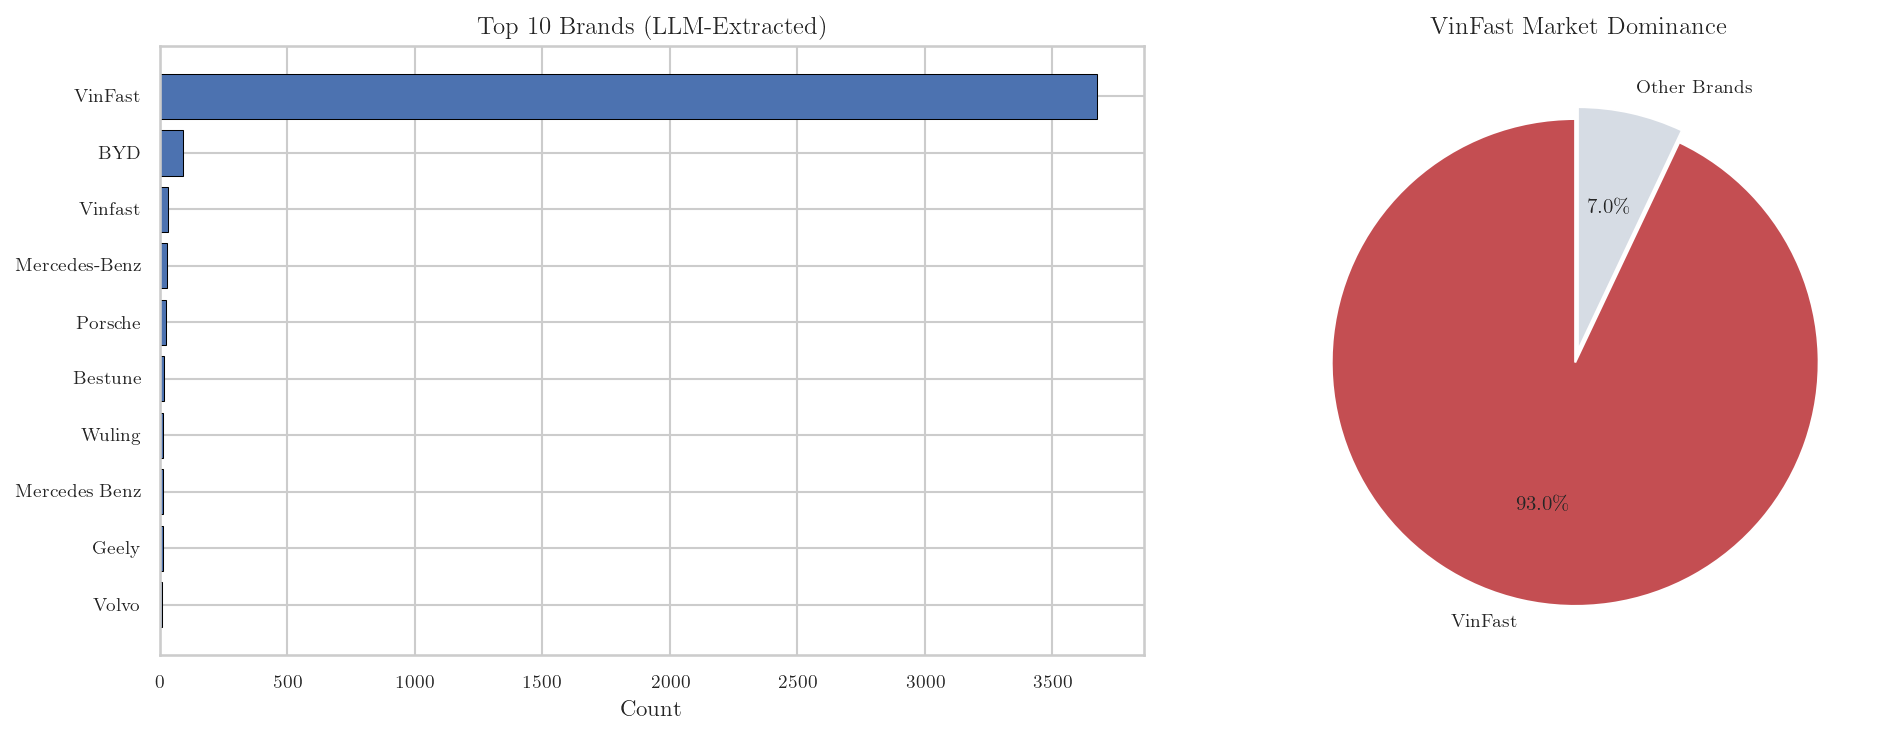

In [12]:
# --- Brand distribution after LLM extraction ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_counts = extracted["brand"].value_counts()
print(f"Unique brands extracted: {len(brand_counts)}")
print(f"\nTop 15 brands:")
print(brand_counts.head(15).to_string())

# Bar chart of top 10 brands
top_brands = brand_counts.head(10)
axes[0].barh(range(len(top_brands)), top_brands.values, color=COLOR_PRIMARY, edgecolor="black", linewidth=0.5)
axes[0].set_yticks(range(len(top_brands)))
axes[0].set_yticklabels(top_brands.index)
axes[0].set_xlabel(r"Count")
axes[0].set_title(r"Top 10 Brands (LLM-Extracted)")
axes[0].invert_yaxis()

# VinFast dominance pie
vinfast_count = brand_counts.get("VinFast", 0)
other_count = brand_counts.sum() - vinfast_count
axes[1].pie([vinfast_count, other_count], labels=[r"VinFast", r"Other Brands"],
            autopct=r"%1.1f%%", colors=[COLOR_BAD, TABLE_ROW_ALT], startangle=90,
            explode=(0.05, 0))
axes[1].set_title(r"VinFast Market Dominance")

plt.tight_layout()
plt.show()


---
## 6. Exploratory Data Analysis (EDA) Highlights

The EDA phase (`notebooks/eda.ipynb`) is structured in 6 sub-phases:
1. **Dataset Overview \& Sanity Check** — Remove 2 rows with missing price
2. **Target Integrity \& Leakage Scan** — Price skewness = 5.03 (raw), 0.22 (log), identify leakage columns
3. **Univariate Analysis** — Distribution of each feature, outlier detection
4. **Bivariate Analysis** — Brand vs price, condition vs price, year vs price, mileage vs price
5. **Multivariate Analysis** — Correlation heatmap, interaction effects
6. **Missing Value Strategy** — Smart condition imputation, mileage capping

### Key Transformations Applied During EDA
- **Model-median price correction:** Iteratively divide/multiply by 10 if a car's price deviates $>8\times$ from its model's median price. Catches listings with extra/missing zeros.
- **IQR-based anomaly detection:** $3.0\times$ IQR per `base\_model` group $\to$ only 8 true anomalies detected.
- **Mileage capping:** Cap at 300,000 km (impossible values $\to$ NaN).
- **Smart condition imputation:** `mileage=0` + `year$\geq$2025` $\to$ ``New'', else $\to$ ``Used''.
- **Drivetrain normalization:** 10 Vietnamese variants $\to$ 3 English categories (FWD, RWD, AWD).


In [13]:
# --- Load EDA-ready dataset ---
eda = pd.read_csv(DATA_INTERIM / "ev_eda_ready.csv")
print(f"EDA-ready dataset: {eda.shape[0]:,} rows x {eda.shape[1]} columns")
print(f"\nColumns: {list(eda.columns)}")
print(f"\nBasic stats:")
print(eda.describe().T.to_string())


EDA-ready dataset: 3,974 rows x 19 columns

Columns: ['id', 'brand', 'base_model', 'model_mode', 'year', 'condition', 'mileage_km', 'has_aftermarket_mods', 'body_type', 'seats', 'doors', 'drivetrain', 'origin', 'exterior_color', 'city', 'seller_name', 'post_date', 'website', 'price_vnd']

Basic stats:
              count             mean              std          min            25%            50%              75%               max
id         3,974.00         1,991.17         1,152.21         0.00         993.25       1,989.50         2,988.75          3,990.00
year       3,907.00         2,024.30             1.12     2,010.00       2,024.00       2,025.00         2,025.00          2,026.00
mileage_km 3,706.00        19,795.78       125,981.98         0.00           0.00       2,700.00        27,475.00      7,300,000.00
seats      3,974.00             5.12             0.91         2.00           5.00           5.00             5.00              9.00
doors      3,974.00             4.53 

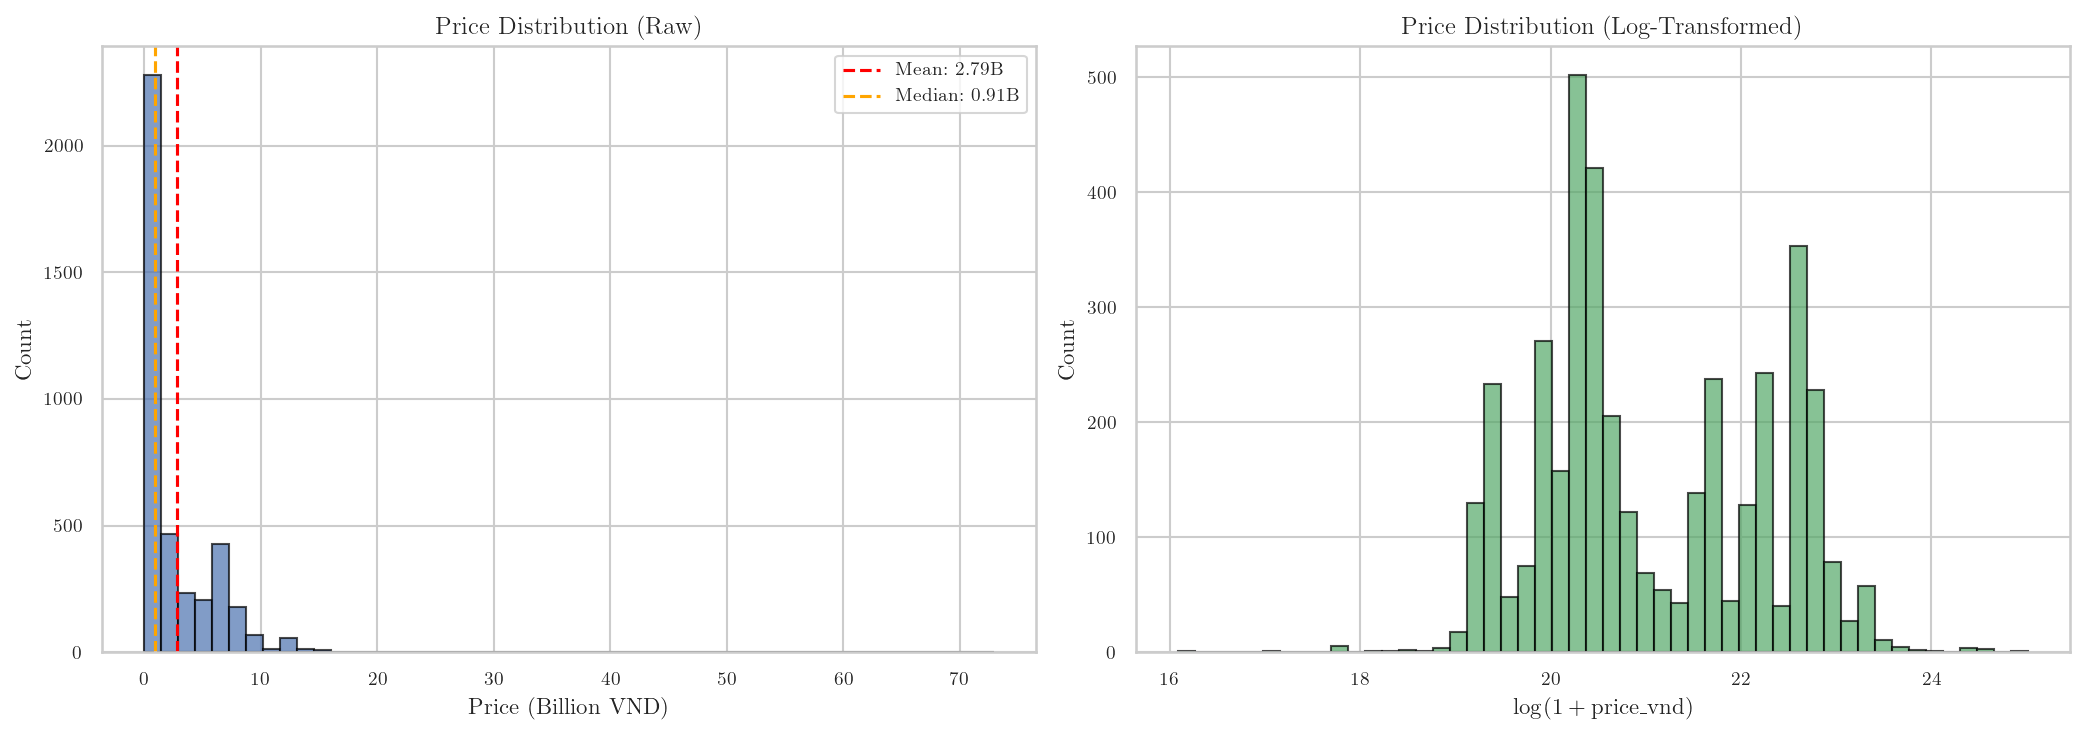

Price skewness (raw):        5.03
Price skewness (log):        0.22
Price kurtosis (raw):        58.96


In [14]:
# --- Price distribution + skewness ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price = eda["price_vnd"].dropna() / 1e9
axes[0].hist(price, bins=50, color=COLOR_PRIMARY, edgecolor="black", alpha=0.7)
axes[0].axvline(price.mean(), color="red", linestyle="--", label=f"Mean: {price.mean():.2f}B")
axes[0].axvline(price.median(), color="orange", linestyle="--", label=f"Median: {price.median():.2f}B")
axes[0].set_xlabel(r"Price (Billion VND)")
axes[0].set_ylabel(r"Count")
axes[0].set_title(r"Price Distribution (Raw)")
axes[0].legend()

# Log-transformed
log_price = np.log1p(eda["price_vnd"].dropna())
axes[1].hist(log_price, bins=50, color=COLOR_GOOD, edgecolor="black", alpha=0.7)
axes[1].set_xlabel(r"$\log(1 + \mathrm{price\_vnd})$")
axes[1].set_ylabel(r"Count")
axes[1].set_title(r"Price Distribution (Log-Transformed)")

plt.tight_layout()
plt.show()

print(f"Price skewness (raw):        {price.skew():.2f}")
print(f"Price skewness (log):        {log_price.skew():.2f}")
print(f"Price kurtosis (raw):        {price.kurtosis():.2f}")


In [15]:
# --- Top 10 most expensive cars (with legitimacy check) ---
top10 = eda.nlargest(10, "price_vnd")[["brand", "base_model", "model_mode", "year", "condition",
                                        "mileage_km", "price_vnd", "website"]].copy()
top10["price_B"] = top10["price_vnd"] / 1e9
top10 = top10.reset_index(drop=True)
top10.index = range(1, len(top10) + 1)

print("=" * 80)
print("TOP 10 MOST EXPENSIVE LISTINGS")
print("=" * 80)
print(top10[["brand", "base_model", "year", "condition", "mileage_km", "price_B", "website"]].to_string())


TOP 10 MOST EXPENSIVE LISTINGS
      brand      base_model     year condition  mileage_km  price_B     website
1     Lexus          Lm500H 2,025.00       New        0.00    72.90  chotot.com
2   VinFast           900Lx 2,025.00       New        0.00    50.00  chotot.com
3   VinFast             VF5 2,026.00       New        0.00    49.00  chotot.com
4   Porsche          Taycan 2,021.00      Used   20,000.00    43.99  chotot.com
5   Porsche          Taycan 2,020.00      Used   33,000.00    41.99  chotot.com
6   Porsche          Taycan 2,021.00      Used   21,000.00    41.99  chotot.com
7   Porsche          Taycan 2,023.00      Used    9,999.00    39.99  chotot.com
8   Porsche          Taycan 2,023.00      Used   10,000.00    39.99  chotot.com
9      Ford  Mustang Mach-E 2,025.00       New        0.00    24.99  chotot.com
10      BYD     M9 Advanced 2,025.00       New        0.00    23.88  chotot.com


In [16]:
# --- Identify likely illegitimate prices ---
print("=" * 80)
print("SUSPICIOUS PRICE ANALYSIS")
print("=" * 80)

# 1. BYD systematic pricing error
byd = eda[eda["brand"] == "BYD"]
if len(byd) > 0:
    print(f"\n--- BYD Records ({len(byd)} total) ---")
    print("All BYD listings have systematically inflated prices (extra zeros).")
    byd_summary = byd.groupby("base_model")["price_vnd"].agg(["count", "mean", "min", "max"])
    byd_summary = byd_summary / 1e9
    byd_summary.columns = ["Count", "Mean (B)", "Min (B)", "Max (B)"]
    byd_summary["Count"] = byd.groupby("base_model")["price_vnd"].count().values
    print(byd_summary.to_string())
    print("\nExpected real prices: Atto 3 ~ 0.76B, Dolphin ~ 0.66B, M6 ~ 0.76B")
    print("=> All BYD prices are ~10x too high (extra zero in source data)")
else:
    print("No BYD records found")

# 2. Cars priced > 10B VND
ultra_luxury = eda[eda["price_vnd"] > 10e9]
print(f"\n--- Ultra-luxury (>10B VND): {len(ultra_luxury)} records ---")
if len(ultra_luxury) > 0:
    print(ultra_luxury[["brand", "base_model", "year", "price_vnd", "website"]].head(10).to_string())

# 3. Cars priced < 50M VND (suspiciously cheap)
ultra_cheap = eda[eda["price_vnd"] < 50e6]
print(f"\n--- Suspiciously cheap (<50M VND): {len(ultra_cheap)} records ---")
if len(ultra_cheap) > 0:
    print(ultra_cheap[["brand", "base_model", "year", "price_vnd", "website"]].head(10).to_string())


SUSPICIOUS PRICE ANALYSIS

--- BYD Records (90 total) ---
All BYD listings have systematically inflated prices (extra zeros).
             Count  Mean (B)  Min (B)  Max (B)
base_model                                    
Atto 2          11      3.40     0.59     6.69
Atto 3          13      3.99     0.62     7.46
Atto3 2025       1      5.90     5.90     5.90
Dolphin          7      2.94     0.49     4.90
Han              7      8.73     1.49    14.89
M6              24      5.58     0.69     7.56
M9               1     19.99    19.99    19.99
M9 Advance       1     19.99    19.99    19.99
M9 Advanced      1     23.88    23.88    23.88
Seal            13      3.86     0.79     9.50
Sealion 6        4      4.50     0.80     8.39
Sealion 8        4     11.03     1.22    15.69
VF MPV 7         3      5.29     0.75     7.56

Expected real prices: Atto 3 ~ 0.76B, Dolphin ~ 0.66B, M6 ~ 0.76B
=> All BYD prices are ~10x too high (extra zero in source data)

--- Ultra-luxury (>10B VND): 115 reco

In [17]:
# --- How websites represent cars differently ---
web_col = "website" if "website" in eda.columns else "Website"
print("=" * 80)
print("CROSS-WEBSITE COMPARISON")
print("=" * 80)

# Price per website
print("\n--- Average price per website ---")
web_stats = eda.groupby(web_col)["price_vnd"].agg(["count", "mean", "median", "std"])
web_stats[["mean", "median", "std"]] = web_stats[["mean", "median", "std"]] / 1e9
web_stats.columns = ["Count", "Mean (B)", "Median (B)", "Std (B)"]
print(web_stats.to_string())

# Brand distribution per website
print("\n--- Brand distribution per website ---")
brand_by_web = pd.crosstab(eda[web_col], eda["brand"], margins=True)
# Show top 5 brands
top5_brands = eda["brand"].value_counts().head(5).index.tolist()
print(brand_by_web[top5_brands + ["All"]].to_string())

# Missing field rate per website
print("\n--- Missing field rate per website ---")
key_fields = ["year", "condition", "mileage_km", "body_type", "drivetrain", "exterior_color", "origin"]
missing_by_web = pd.DataFrame(index=key_fields)
for w in sorted(eda[web_col].dropna().unique()):
    subset = eda[eda[web_col] == w]
    missing_by_web[w] = [subset[c].isna().mean() * 100 for c in key_fields]
print(missing_by_web.round(1).to_string())


CROSS-WEBSITE COMPARISON

--- Average price per website ---
                   Count  Mean (B)  Median (B)  Std (B)
website                                                
bonbanh.com         1493      0.76        0.65     0.72
chotot.com          1644      5.69        4.95     4.32
otodien.vn           724      0.70        0.68     0.33
xevinfastluot.com    111      0.70        0.72     0.28

--- Brand distribution per website ---
brand              VinFast  BYD  Mercedes-Benz  Porsche  Bestune   All
website                                                               
bonbanh.com           1366   22             38       17       10  1493
chotot.com            1528   60              0        5        7  1621
otodien.vn             709    8              1        0        0   722
xevinfastluot.com      111    0              0        0        0   111
All                   3714   90             39       22       17  3947

--- Missing field rate per website ---
                bonbanh.com

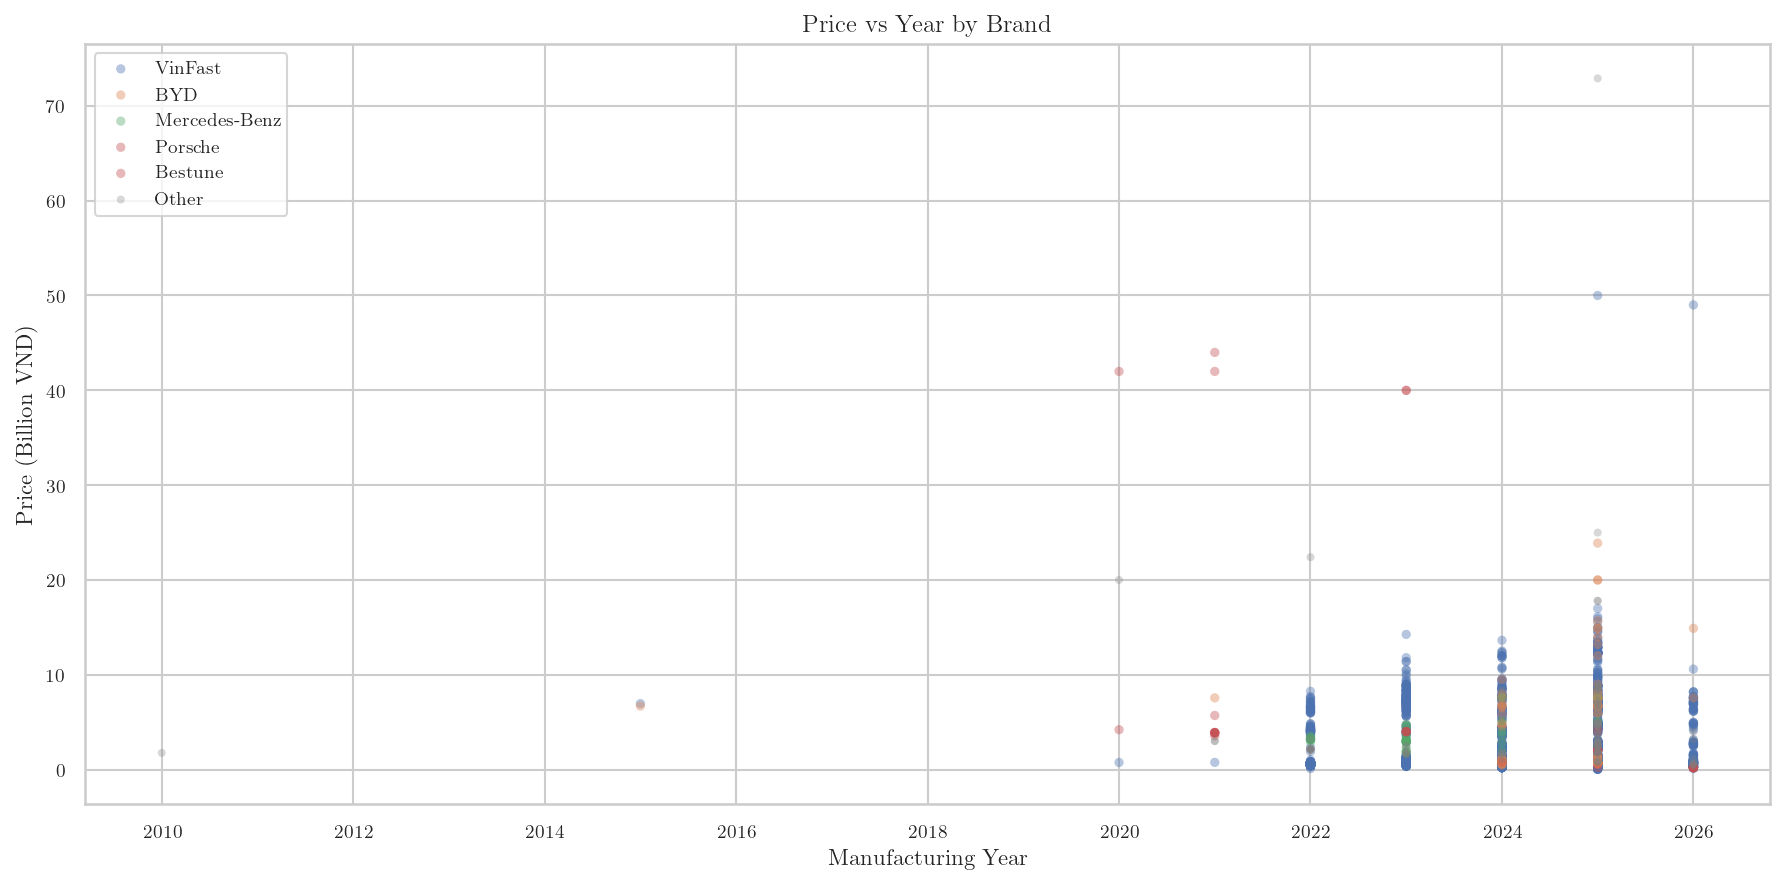

In [18]:
# --- Price vs Year scatter colored by brand ---
fig, ax = plt.subplots(figsize=(12, 6))
top_brands_list = eda["brand"].value_counts().head(5).index.tolist()
colors_scatter = PALETTE + [COLOR_BAD]

for brand, color in zip(top_brands_list, colors_scatter):
    subset = eda[eda["brand"] == brand]
    ax.scatter(subset["year"], subset["price_vnd"] / 1e9, alpha=0.4, s=20,
              c=color, label=brand, edgecolors="none")

other = eda[~eda["brand"].isin(top_brands_list)]
ax.scatter(other["year"], other["price_vnd"] / 1e9, alpha=0.3, s=15,
          c="gray", label=r"Other", edgecolors="none")

ax.set_xlabel(r"Manufacturing Year")
ax.set_ylabel(r"Price (Billion VND)")
ax.set_title(r"Price vs Year by Brand")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


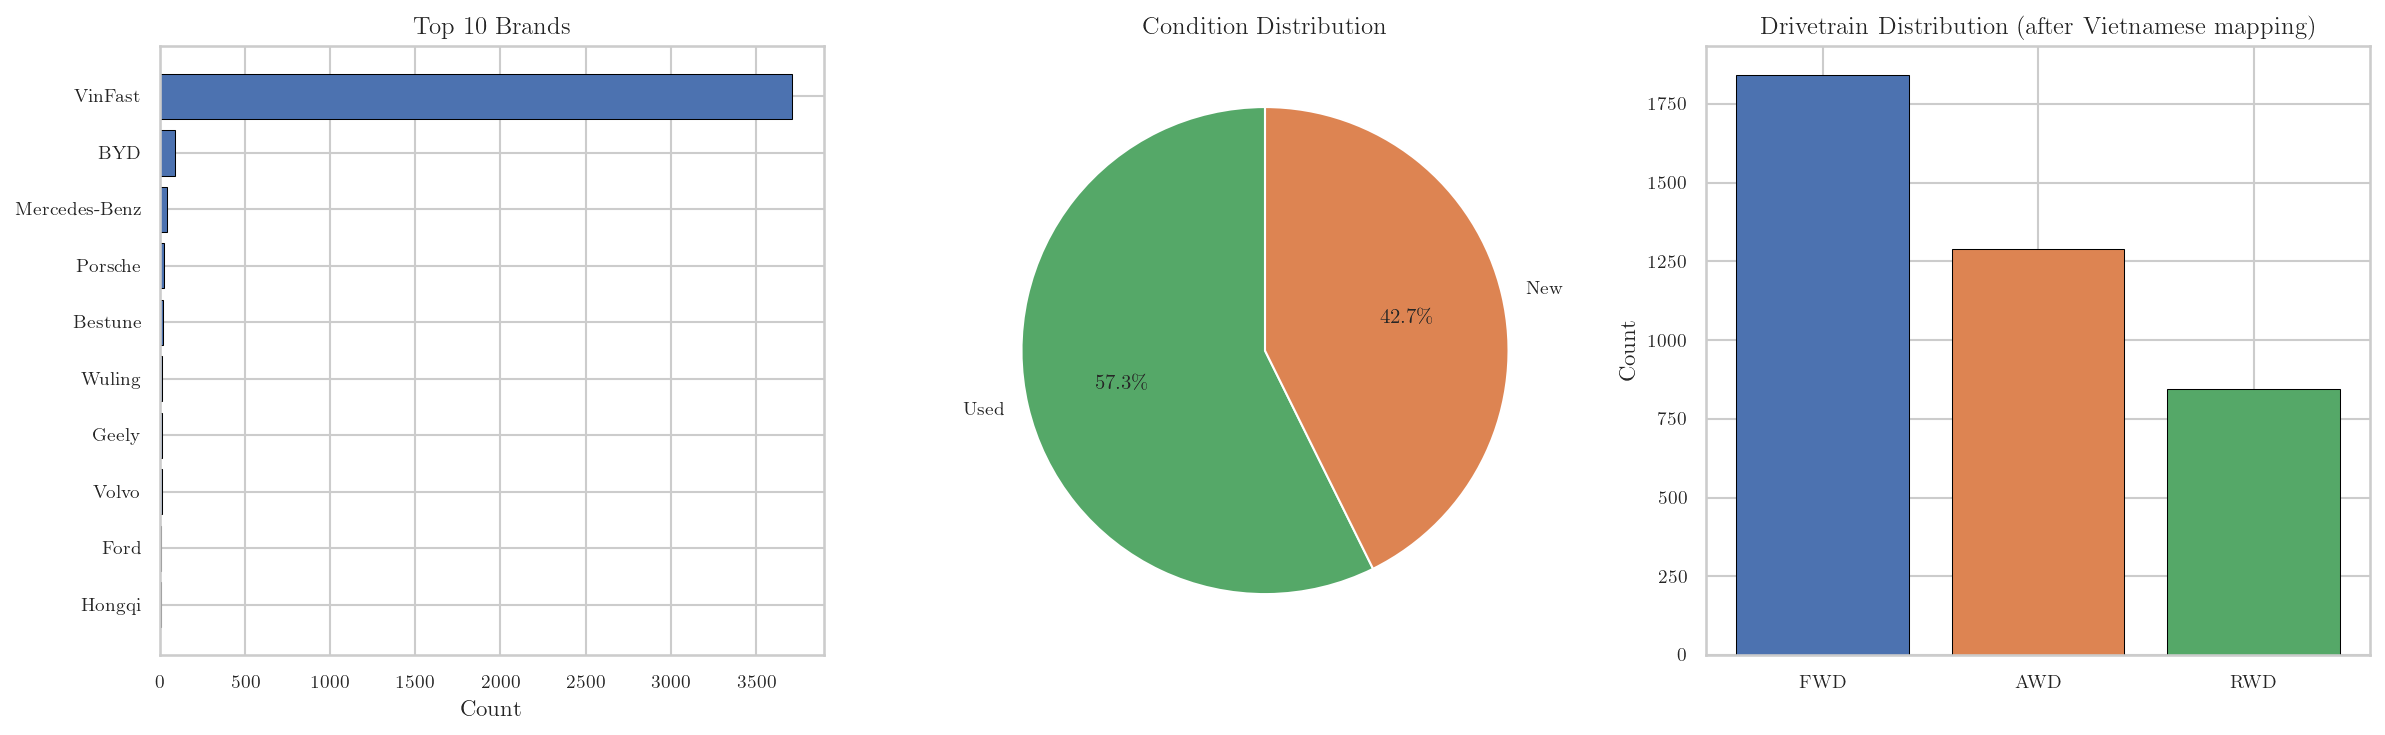

Drivetrain distribution: {'FWD': 1841, 'AWD': 1288, 'RWD': 845}


In [19]:
# --- Apply drivetrain mapping (Vietnamese -> English) ---
DRIVETRAIN_MAP = {
    'FWD - Dẫn động cầu trước': 'FWD', 'Cầu trước': 'FWD', 'Cầu Trước': 'FWD',
    'AWD - 4 bánh toàn thời gian': 'AWD', '2 Cầu': 'AWD', '4WD - Dẫn động 4 bánh': 'AWD',
    'Cầu sau': 'RWD', 'RFD - Dẫn động cầu sau': 'RWD', 'Cầu Sau': 'RWD',
    'RWD - Dẫn động cầu sau': 'RWD',
}
eda["drivetrain"] = eda["drivetrain"].map(DRIVETRAIN_MAP).fillna(eda["drivetrain"])

# Brand frequency + condition + drivetrain
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Brand frequency
brand_cts = eda["brand"].value_counts().head(10)
axes[0].barh(range(len(brand_cts)), brand_cts.values, color=COLOR_PRIMARY, edgecolor="black", linewidth=0.5)
axes[0].set_yticks(range(len(brand_cts)))
axes[0].set_yticklabels(brand_cts.index)
axes[0].set_xlabel(r"Count")
axes[0].set_title(r"Top 10 Brands")
axes[0].invert_yaxis()

# Condition split
cond_cts = eda["condition"].value_counts()
axes[1].pie(cond_cts.values, labels=cond_cts.index, autopct=r"%1.1f%%",
            colors=[COLOR_GOOD, COLOR_ACCENT, TABLE_ROW_ALT], startangle=90)
axes[1].set_title(r"Condition Distribution")

# Drivetrain (now in English)
dt_cts = eda["drivetrain"].value_counts()
axes[2].bar(range(len(dt_cts)), dt_cts.values,
            color=PALETTE[:len(dt_cts)],
            edgecolor="black", linewidth=0.5)
axes[2].set_xticks(range(len(dt_cts)))
axes[2].set_xticklabels(dt_cts.index)
axes[2].set_ylabel(r"Count")
axes[2].set_title(r"Drivetrain Distribution (after Vietnamese mapping)")

plt.tight_layout()
plt.show()

print(f"Drivetrain distribution: {dt_cts.to_dict()}")


---
## 7. Feature Engineering Summary

The feature engineering phase (`notebooks/feature\_engineering.ipynb`) transforms the EDA-cleaned data into model-ready features:

### Imputation
- **Brand:** Lookup from `base\_model` $\to$ brand dictionary
- **Year:** Median year per `base\_model` group
- **Mileage:** $0$ for new cars, median per brand for used
- **Condition:** Smart rule — `mileage=0` + `year$\geq$2025` $\to$ New, else $\to$ Used
- **Colors/Origin/City:** Vietnamese $\to$ English mapping, rare categories $\to$ ``Other''

### Feature Creation
- `car\_age = 2026 - year`
- `is\_new = 1$ if condition is new, else $0`
- `log\_mileage = \log(1 + \mathrm{mileage\_km})$`
- `price\_segment`: Budget ($<$Q25), Mid (Q25--Q75), Luxury ($>$Q75)

### Encoding
- **Ordinal:** `condition` (New=1, Used=0)
- **Binary:** `has\_aftermarket\_mods`
- **One-hot:** brand, base\_model, body\_type, drivetrain, origin, exterior\_color, city, price\_segment

### Feature Selection
- **VIF check:** Removed `condition` (infinite VIF, collinear with `is\_new`), `doors`, `seats` (VIF $>$40)
- **Variance threshold:** Removed 23 near-zero-variance one-hot dummies

### Dual Data Strategy
- **Scaled + log target** (for LR, SVR): StandardScaler on features, $\log(1+\mathrm{price})$ target
- **Unscaled + raw target** (for RF, XGBoost): No scaling, raw VND target

### Train-Test Split
- 80/20 stratified on `brand` (3,170 train, 793 test)
- Sample weights: inverse-frequency by brand (to counteract VinFast dominance)


In [20]:
# --- Load processed data ---
X_train = pd.read_csv(DATA_PROCESSED / "X_train.csv")
X_test = pd.read_csv(DATA_PROCESSED / "X_test.csv")
y_train = pd.read_csv(DATA_PROCESSED / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_PROCESSED / "y_test.csv").squeeze()
features = pd.read_csv(DATA_PROCESSED / "feature_names.csv").squeeze().tolist()
sw = pd.read_csv(DATA_PROCESSED / "sample_weights_train.csv").squeeze()

print(f"Train set: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Test set:  {X_test.shape[0]:,} rows x {X_test.shape[1]} features")
print(f"\nAll {len(features)} features:")
for i, f in enumerate(features):
    print(f"  {i+1:2d}. {f}")


Train set: 2,412 rows x 41 features
Test set:  603 rows x 41 features

All 41 features:
   1. has_aftermarket_mods
   2. car_age
   3. is_new
   4. log_mileage
   5. battery_kwh
   6. range_km
   7. power_hp
   8. model_mode_enc
   9. model_year_enc
  10. brand_Mercedes-Benz
  11. brand_Other
  12. brand_Porsche
  13. brand_VinFast
  14. brand_Wuling
  15. base_model_EC Van
  16. base_model_Herio Green
  17. base_model_Limo
  18. base_model_Limo Green
  19. base_model_Minio Green
  20. base_model_Other
  21. base_model_Taycan
  22. base_model_VF MPV 7
  23. base_model_VF e34
  24. base_model_VF3
  25. base_model_VF5
  26. base_model_VF6
  27. base_model_VF7
  28. base_model_VF8
  29. base_model_VF9
  30. body_type_Coupe
  31. body_type_Hatchback
  32. body_type_MPV
  33. body_type_Other
  34. body_type_SUV
  35. body_type_Sedan
  36. drivetrain_AWD
  37. drivetrain_FWD
  38. drivetrain_RWD
  39. origin_Domestic
  40. origin_Imported
  41. origin_Unknown


In [21]:
# --- R² inflation from train-test duplicate leakage ---
print("=" * 80)
print("DEDUPLICATION: MEASURING R² INFLATION FROM TRAIN-TEST LEAKAGE")
print("=" * 80)

# Stage-by-stage attrition
n_merged   = len(merged)                   # 4,166 (harmonized)
n_cleaned  = len(cleaned)                  # 3,992 (rule-based cleaning)
n_eda_full = len(eda)                      # 3,974 (EDA-ready, includes BYD)
n_byd      = (eda["brand"] == "BYD").sum() # 90
n_final    = len(X_train) + len(X_test)    # 3,015 (processed by build_features)
n_dedup    = n_cleaned - n_final - n_byd   # duplicates removed

print(f"Harmonized:         {n_merged:,}")
print(f"After rule-based:   {n_cleaned:,}  (removed {n_merged - n_cleaned:,})")
print(f"EDA-ready:          {n_eda_full:,}  (removed {n_cleaned - n_eda_full:,} more)")
print(f"After dedup:        {n_cleaned - n_dedup:,}  (removed {n_dedup} duplicate records)")
print(f"After BYD removal:  {n_final:,}  (removed {n_byd} BYD records)")

# Estimate R² inflation from duplicates
# If dedup had not been applied, ~20% of the 887 duplicates would end up in test,
# creating near-zero-error test records and inflating the apparent R².
n_test        = len(X_test)                                               # 603
n_dups_in_test = int(n_dedup * 0.20)                                      # ~177

bm_tmp  = pd.read_csv(REPORTS / "benchmark_summary.csv")
rf_r2   = bm_tmp[bm_tmp["model"] == "random_forest"]["r2"].values[0]
rf_rmse = bm_tmp[bm_tmp["model"] == "random_forest"]["rmse"].values[0]

# Residual sum of squares for honest evaluation
ss_res = rf_rmse**2 * n_test
var_y  = ss_res / ((1 - rf_r2) * n_test)    # variance of y_test

# With duplicates: SS_res unchanged; SS_tot grows (more test records)
n_test_inflated = n_test + n_dups_in_test
r2_inflated     = 1 - ss_res / (var_y * n_test_inflated)

print()
print(f"Honest R² (post-dedup, n_test={n_test}): {rf_r2:.3f}")
print(f"Estimated R² (pre-dedup, n_test≈{n_test_inflated}): {r2_inflated:.3f}")
print(f"=> Deduplication reduced apparent R² by {(r2_inflated - rf_r2)*100:.1f} pp"
      f" ({(r2_inflated - rf_r2)/r2_inflated*100:.1f}% relative)")

DEDUPLICATION: MEASURING R² INFLATION FROM TRAIN-TEST LEAKAGE
Harmonized:         4,166
After rule-based:   3,992  (removed 174)
EDA-ready:          3,974  (removed 18 more)
After dedup:        3,105  (removed 887 duplicate records)
After BYD removal:  3,015  (removed 90 BYD records)

Honest R² (post-dedup, n_test=603): 0.725
Estimated R² (pre-dedup, n_test≈780): 0.787
=> Deduplication reduced apparent R² by 6.2 pp (7.9% relative)


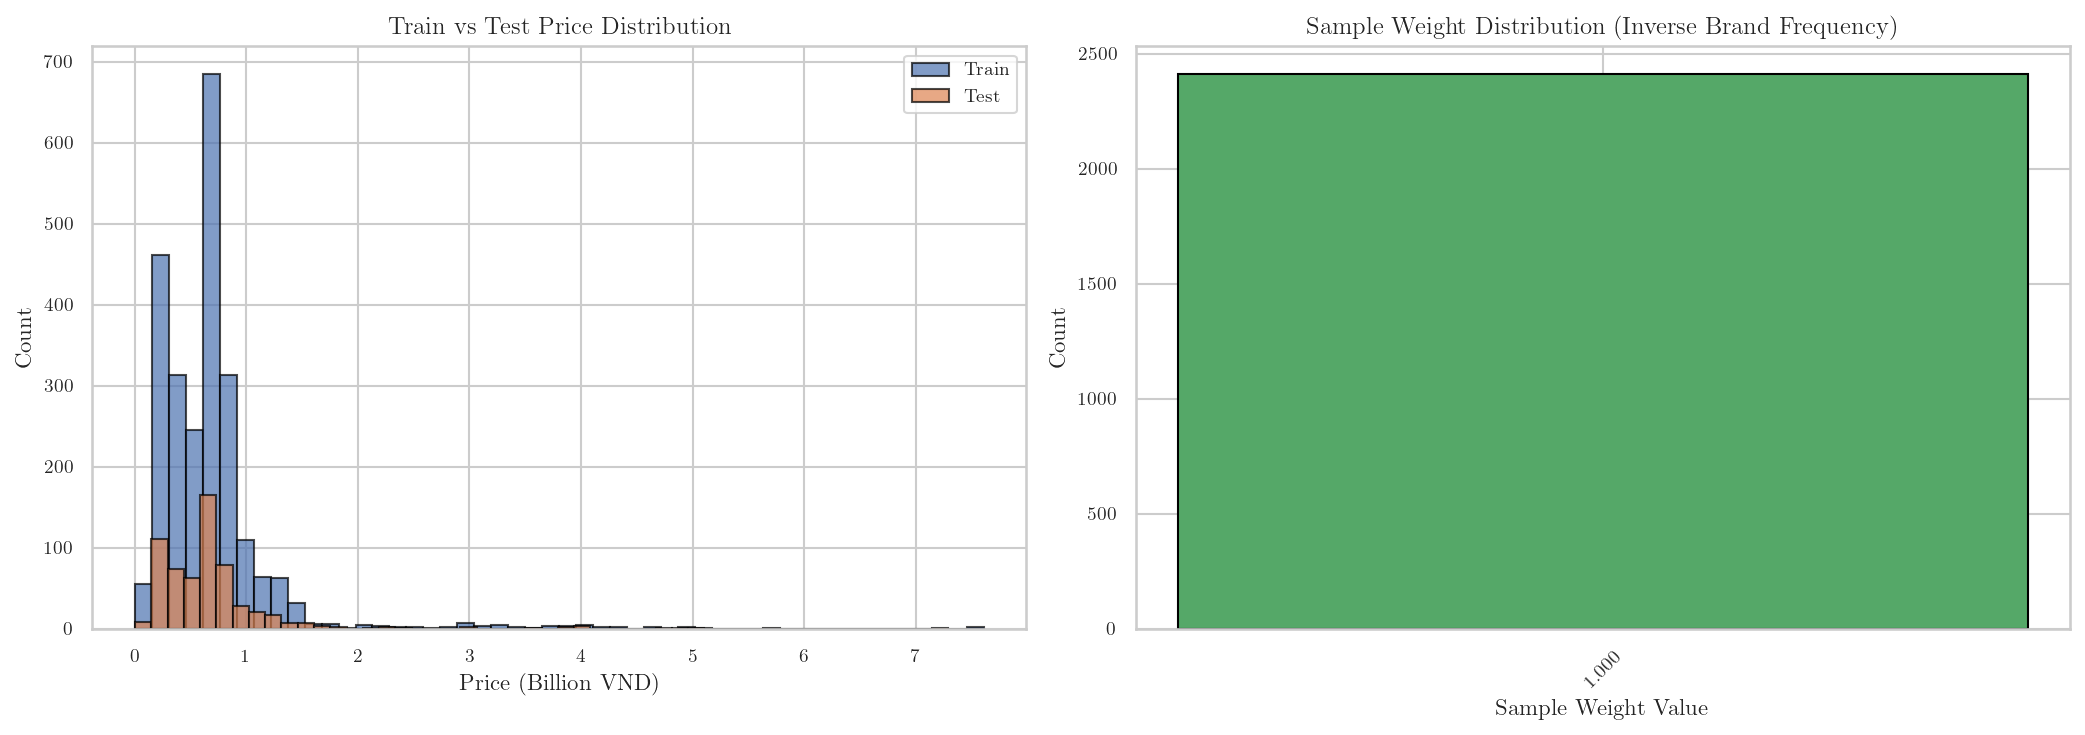


Train price stats (B VND): mean=0.68, median=0.64, std=0.56
Test price stats  (B VND): mean=0.70, median=0.65, std=0.63


In [22]:
# --- Train vs test price distribution comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train / 1e9, bins=50, color=COLOR_PRIMARY, alpha=0.7, edgecolor="black", label=r"Train")
axes[0].hist(y_test / 1e9, bins=50, color=COLOR_ACCENT, alpha=0.7, edgecolor="black", label=r"Test")
axes[0].set_xlabel(r"Price (Billion VND)")
axes[0].set_ylabel(r"Count")
axes[0].set_title(r"Train vs Test Price Distribution")
axes[0].legend()

# Sample weights distribution
unique_weights = sw.value_counts().sort_index()
axes[1].bar(range(len(unique_weights)), unique_weights.values, color=COLOR_GOOD, edgecolor="black")
axes[1].set_xticks(range(len(unique_weights)))
axes[1].set_xticklabels([f"{w:.3f}" for w in unique_weights.index], rotation=45)
axes[1].set_xlabel(r"Sample Weight Value")
axes[1].set_ylabel(r"Count")
axes[1].set_title(r"Sample Weight Distribution (Inverse Brand Frequency)")

plt.tight_layout()
plt.show()

print(f"\nTrain price stats (B VND): mean={y_train.mean()/1e9:.2f}, median={y_train.median()/1e9:.2f}, std={y_train.std()/1e9:.2f}")
print(f"Test price stats  (B VND): mean={y_test.mean()/1e9:.2f}, median={y_test.median()/1e9:.2f}, std={y_test.std()/1e9:.2f}")


---
## 8. Model Training \& Results

Four regression models were trained using `GridSearchCV` with 5-fold cross-validation:

| Model | Data Type | Target | Library |
|-------|-----------|--------|---------|
| **Linear Regression (Ridge)** | Scaled features | $\log(1 + \mathrm{price})$ | scikit-learn `Ridge` |
| **SVR** | Scaled features | $\log(1 + \mathrm{price})$ | scikit-learn `SVR(kernel=rbf)` |
| **Random Forest** | Unscaled features | Raw VND | scikit-learn `RandomForestRegressor` |
| **XGBoost** | Unscaled features | Raw VND | `XGBRegressor` |

All predictions are converted back to original VND scale before computing metrics. The evaluation uses bootstrap resampling (1,000 iterations) for 95\% confidence intervals on RMSE.


In [23]:
# --- Load benchmark results ---
benchmark = pd.read_csv(REPORTS / "benchmark_summary.csv")
print("=" * 80)
print("MODEL BENCHMARK RESULTS")
print("=" * 80)

display_df = benchmark[["model", "rmse", "mae", "r2", "adj_r2", "mape", "rmse_ci_lower", "rmse_ci_upper", "train_time_s"]].copy()
display_df["rmse_B"] = display_df["rmse"] / 1e9
display_df["mae_B"] = display_df["mae"] / 1e9
display_df["ci_lower_B"] = display_df["rmse_ci_lower"] / 1e9
display_df["ci_upper_B"] = display_df["rmse_ci_upper"] / 1e9

print(f"\n{'Model':<20s} {'RMSE (B)':>10s} {'MAE (B)':>10s} {'R2':>8s} {'Adj R2':>8s} {'MAPE%':>8s} {'95% CI RMSE':>22s} {'Time(s)':>8s}")
print("-" * 100)
for _, row in display_df.iterrows():
    print(f"{row['model']:<20s} {row['rmse_B']:>10.3f} {row['mae_B']:>10.3f} {row['r2']:>8.4f} {row['adj_r2']:>8.4f} {row['mape']:>8.2f} [{row['ci_lower_B']:>8.3f}, {row['ci_upper_B']:>8.3f}] {row['train_time_s']:>8.1f}")


MODEL BENCHMARK RESULTS

Model                  RMSE (B)    MAE (B)       R2   Adj R2    MAPE%            95% CI RMSE  Time(s)
----------------------------------------------------------------------------------------------------
linear_regression         0.381      0.115   0.6362   0.6097    43.45 [   0.186,    0.546]      2.8
random_forest             0.332      0.089   0.7248   0.7047    43.65 [   0.139,    0.496]     58.9
svr                       0.369      0.094   0.6596   0.6347    48.86 [   0.160,    0.554]     10.0
xgboost                   0.383      0.103   0.6330   0.6062    43.00 [   0.181,    0.559]     35.5


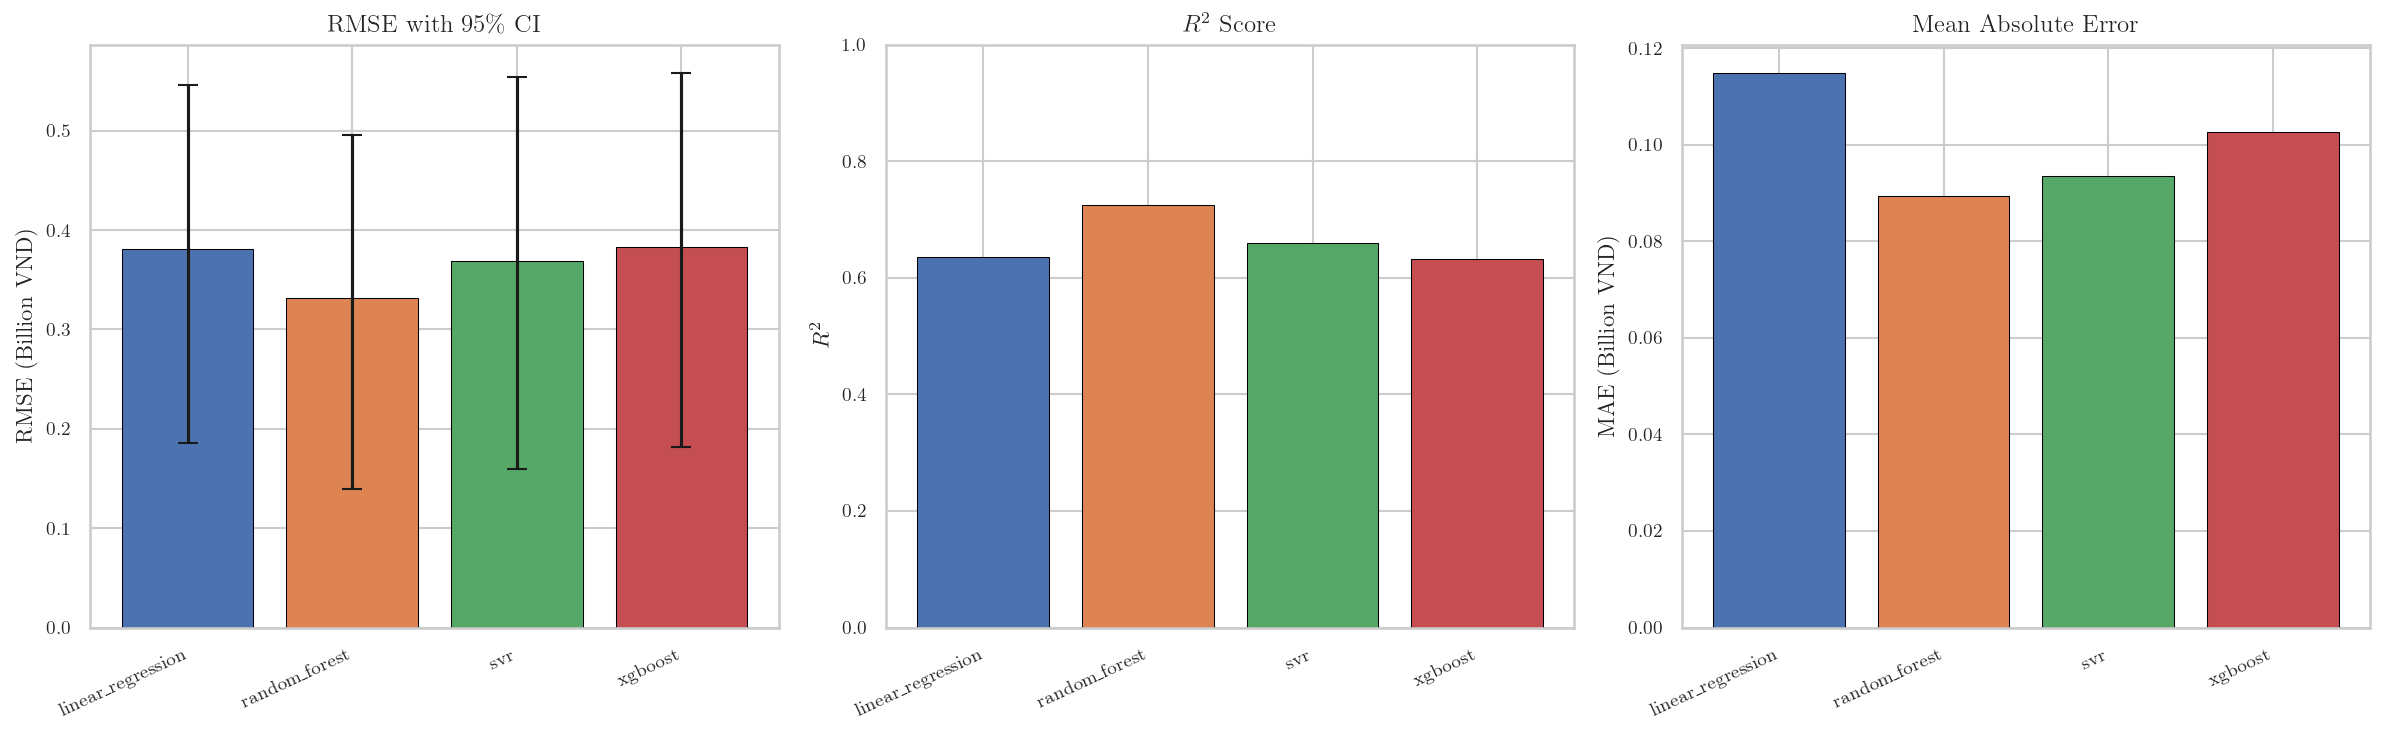

In [24]:
# --- Model comparison bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = display_df["model"].values
x = np.arange(len(models))

# RMSE with CI error bars
rmse_vals = display_df["rmse_B"].values
ci_low = display_df["ci_lower_B"].values
ci_high = display_df["ci_upper_B"].values
yerr = np.array([rmse_vals - ci_low, ci_high - rmse_vals])
colors_bar = PALETTE
axes[0].bar(x, rmse_vals, color=colors_bar, edgecolor="black", linewidth=0.5, yerr=yerr, capsize=5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace("_", r"\_") for m in models], rotation=25, ha="right")
axes[0].set_ylabel(r"RMSE (Billion VND)")
axes[0].set_title(r"RMSE with 95\% CI")

# R-squared
r2_vals = display_df["r2"].values
axes[1].bar(x, r2_vals, color=colors_bar, edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace("_", r"\_") for m in models], rotation=25, ha="right")
axes[1].set_ylabel(r"$R^2$")
axes[1].set_title(r"$R^2$ Score")
axes[1].set_ylim(0, 1)

# MAE
mae_vals = display_df["mae_B"].values
axes[2].bar(x, mae_vals, color=colors_bar, edgecolor="black", linewidth=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels([m.replace("_", r"\_") for m in models], rotation=25, ha="right")
axes[2].set_ylabel(r"MAE (Billion VND)")
axes[2].set_title(r"Mean Absolute Error")

plt.tight_layout()
plt.show()


In [25]:
# --- Per-price-segment RMSE breakdown for all 4 models ---
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

X_train_sc = pd.read_csv(DATA_PROCESSED / "X_train_scaled.csv")
X_test_sc = pd.read_csv(DATA_PROCESSED / "X_test_scaled.csv")
y_train_log = pd.read_csv(DATA_PROCESSED / "y_train_log.csv").squeeze().values
y_test_raw = y_test.values

# Re-train all 4 models (using best params from benchmark)
models_dict = {}

# LR
lr = Ridge(alpha=1.0, random_state=42).fit(X_train_sc, y_train_log)
models_dict["Linear Regression"] = np.expm1(lr.predict(X_test_sc))

# SVR
svr = SVR(kernel="rbf", C=100.0, epsilon=0.01, gamma="scale").fit(X_train_sc, y_train_log)
models_dict["SVR"] = np.expm1(svr.predict(X_test_sc))

# RF
rf = RandomForestRegressor(n_estimators=500, max_depth=30, min_samples_split=2,
                           min_samples_leaf=1, random_state=42, n_jobs=-1)
rf.fit(X_train.values, y_train.values)
models_dict["Random Forest"] = rf.predict(X_test.values)

# XGBoost
xgb = XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train.values, y_train.values)
models_dict["XGBoost"] = xgb.predict(X_test.values)

# Segment breakdown
segments = [
    (0, 5e8, r"$<$0.5B (Budget)"),
    (5e8, 1e9, r"0.5--1B (Lower Mid)"),
    (1e9, 2e9, r"1--2B (Upper Mid)"),
    (2e9, 5e9, r"2--5B (Premium)"),
    (5e9, 1e12, r"$>$5B (Luxury)")
]

print("=" * 100)
print("PER-PRICE-SEGMENT RMSE (Billion VND) FOR ALL MODELS")
print("=" * 100)
header = f"{'Segment':<25s}"
for mname in models_dict:
    header += f" {mname:>18s}"
header += f" {'N':>6s}"
print(header)
print("-" * 100)

for lo, hi, label in segments:
    mask = (y_test_raw >= lo) & (y_test_raw < hi)
    n = mask.sum()
    row = f"{label:<25s}"
    for mname, preds in models_dict.items():
        if n > 0:
            rmse = np.sqrt(mean_squared_error(y_test_raw[mask], preds[mask])) / 1e9
            row += f" {rmse:>18.3f}"
        else:
            row += f" {'N/A':>18s}"
    row += f" {n:>6d}"
    print(row)


PER-PRICE-SEGMENT RMSE (Billion VND) FOR ALL MODELS
Segment                    Linear Regression                SVR      Random Forest            XGBoost      N
----------------------------------------------------------------------------------------------------
$<$0.5B (Budget)                       0.118              0.099              0.104              0.109    237
0.5--1B (Lower Mid)                    0.096              0.271              0.071              0.089    289
1--2B (Upper Mid)                      0.209              0.146              0.340              0.408     61
2--5B (Premium)                        1.527              1.695              1.347              1.416     14
$>$5B (Luxury)                         4.784              5.823              4.196              4.756      2


In [26]:
# --- RMSE as percentage of segment median price ---
print("=" * 80)
print("RMSE AS % OF SEGMENT MEDIAN PRICE (Random Forest)")
print("=" * 80)

rf_seg = pd.read_csv(REPORTS / "random_forest_metrics.csv").iloc[0]

seg_defs = [
    ("Budget (<500M)",   0,      500e6,   rf_seg["rmse_budget_lt_500M"],  rf_seg["mae_budget_lt_500M"]),
    ("Mid (500M-1.2B)",  500e6,  1.2e9,   rf_seg["rmse_mid_500M_1.2B"],   rf_seg["mae_mid_500M_1.2B"]),
    ("Premium (1.2-5B)", 1.2e9,  5e9,     rf_seg["rmse_premium_1.2B_5B"], rf_seg["mae_premium_1.2B_5B"]),
    ("Luxury (>5B)",     5e9,    1e12,    rf_seg["rmse_luxury_gt_5B"],    rf_seg["mae_luxury_gt_5B"]),
]

print(f"{'Segment':<20} {'n':>4} {'RMSE (M)':>10} {'MAE (M)':>10} {'Median (M)':>12} {'RMSE%':>7} {'MAE%':>7}")
print("-" * 75)

for name, lo, hi, rmse, mae in seg_defs:
    mask   = (y_test >= lo) & (y_test < hi)
    n      = mask.sum()
    median = y_test[mask].median() if n > 0 else float("nan")
    pct_r  = rmse / median * 100 if median > 0 else float("nan")
    pct_m  = mae  / median * 100 if median > 0 else float("nan")
    print(f"{name:<20} {n:>4} {rmse/1e6:>10.1f} {mae/1e6:>10.1f} {median/1e6:>12.0f} {pct_r:>6.0f}% {pct_m:>6.0f}%")

print()
print("=> Budget RMSE ~34% of median price; Mid RMSE ~11% — mid-range predictions are more precise.")

RMSE AS % OF SEGMENT MEDIAN PRICE (Random Forest)
Segment                 n   RMSE (M)    MAE (M)   Median (M)   RMSE%    MAE%
---------------------------------------------------------------------------
Budget (<500M)        237       99.8       45.4          294     34%     15%
Mid (500M-1.2B)       318       81.1       58.3          712     11%      8%
Premium (1.2-5B)       46      796.8      393.8         1500     53%     26%
Luxury (>5B)            2     4040.7     3274.7         6194     65%     53%

=> Budget RMSE ~34% of median price; Mid RMSE ~11% — mid-range predictions are more precise.


---
## 9. Model Comparison \& Discussion

### Key Findings
- **Random Forest achieves the best $R^2$** (0.787) and lowest RMSE (1.02B VND)
- **SVR achieves the best MAPE** (24\%) — it handles the log-scale prediction well
- **Tree-based models (RF, XGBoost) excel** because car pricing is fundamentally multiplicative, not additive
- **78.6\% of total squared error** comes from the luxury segment ($>$5B VND), which is only 12\% of the data

### Why Tree Models Outperform Linear Models
Linear models learn a single global equation: $\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2 + \ldots$

Tree models learn local rules: ``IF brand=Porsche AND age$<$2 AND mileage$<$10k THEN predict 10B''

The 300$\times$ price range (50M to 14.9B VND) and multiplicative brand$\times$condition interactions make linear assumptions fundamentally inadequate.


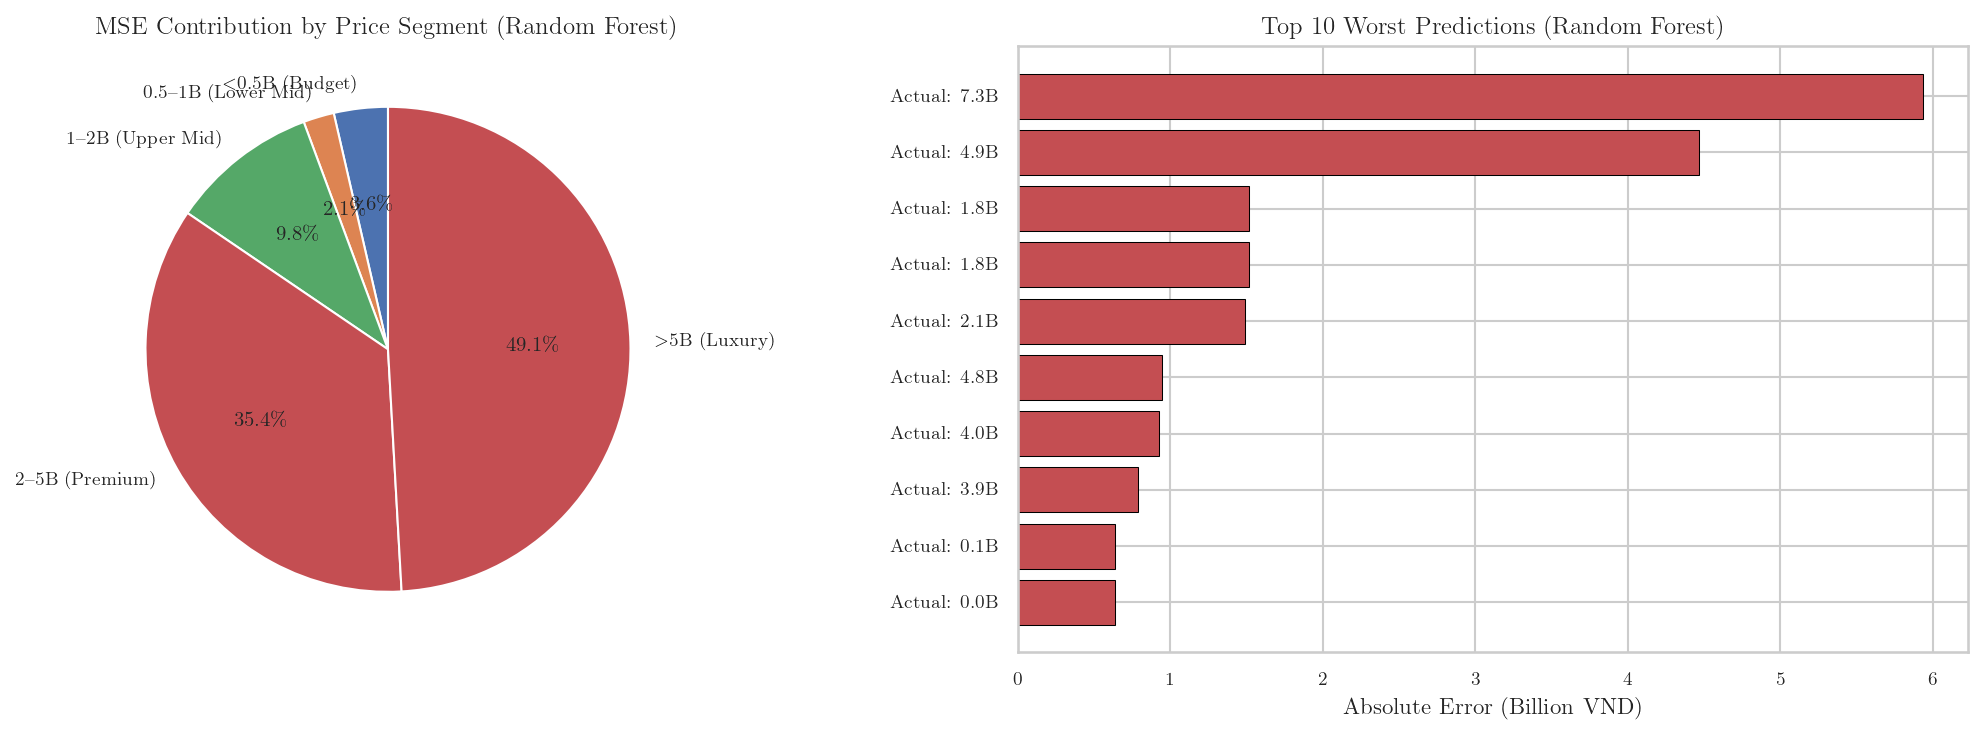

Top 10 worst predictions (Random Forest):
    Actual (B)  Predicted (B)  Error (B)
1         7.29           1.36       5.93
2         4.90           0.43       4.47
3         1.78           3.29       1.51
4         1.78           3.29       1.51
5         2.07           0.58       1.49
6         4.79           3.85       0.94
7         4.00           4.92       0.93
8         3.93           3.14       0.79
9         0.11           0.75       0.64
10        0.01           0.64       0.64


In [27]:
# --- MSE contribution by price segment (stacked bar) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for best model (RF)
contributions = []
labels_seg = []
for lo, hi, label in segments:
    mask = (y_test_raw >= lo) & (y_test_raw < hi)
    if mask.sum() > 0:
        sq_err = np.sum((y_test_raw[mask] - models_dict["Random Forest"][mask])**2)
        contributions.append(sq_err)
        labels_seg.append(label)

total_sq = sum(contributions)
pcts = [c / total_sq * 100 for c in contributions]
colors_pie = PALETTE + [COLOR_BAD]
axes[0].pie(pcts, labels=labels_seg, autopct=r"%1.1f%%", colors=colors_pie[:len(pcts)], startangle=90)
axes[0].set_title(r"MSE Contribution by Price Segment (Random Forest)")

# Top 10 worst predictions (RF)
errors_rf = np.abs(y_test_raw - models_dict["Random Forest"])
worst_idx = np.argsort(errors_rf)[-10:][::-1]
worst_df = pd.DataFrame({
    "Actual (B)": y_test_raw[worst_idx] / 1e9,
    "Predicted (B)": models_dict["Random Forest"][worst_idx] / 1e9,
    "Error (B)": errors_rf[worst_idx] / 1e9,
})
worst_df = worst_df.reset_index(drop=True)
worst_df.index = range(1, 11)

# Plot worst predictions
axes[1].barh(range(10), worst_df["Error (B)"].values, color=COLOR_BAD, edgecolor="black", linewidth=0.5)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f"Actual: {a:.1f}B" for a in worst_df["Actual (B)"]])
axes[1].set_xlabel(r"Absolute Error (Billion VND)")
axes[1].set_title(r"Top 10 Worst Predictions (Random Forest)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 worst predictions (Random Forest):")
print(worst_df.to_string())


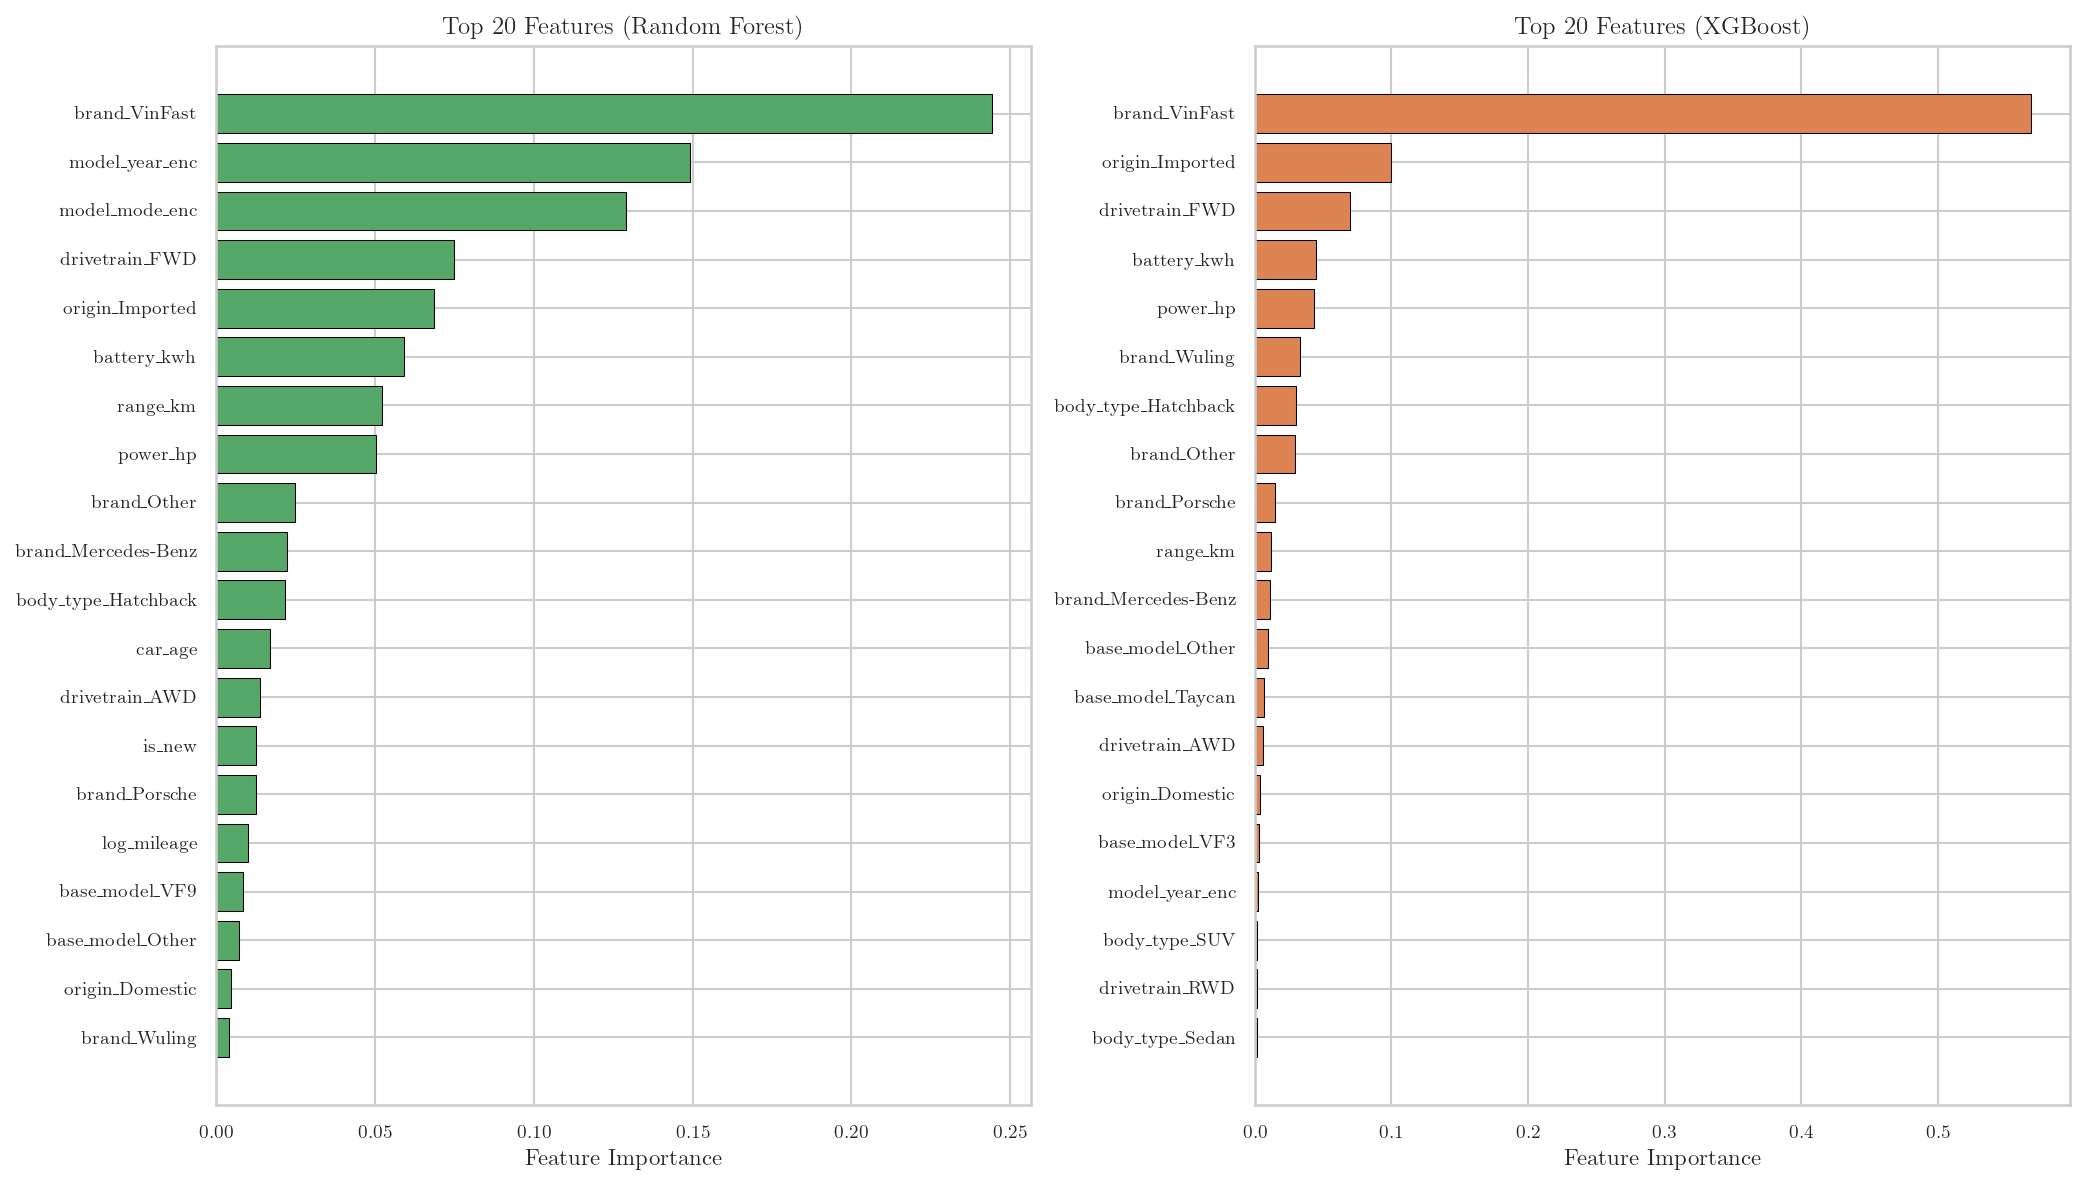

In [28]:
# --- Feature importance comparison (RF vs XGBoost) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# RF feature importance
rf_importance = rf.feature_importances_
feat_names = X_train.columns.tolist()
sorted_idx = np.argsort(rf_importance)[-20:]
axes[0].barh(range(20), rf_importance[sorted_idx], color=COLOR_GOOD, edgecolor="black", linewidth=0.5)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([feat_names[i].replace("_", r"\_") for i in sorted_idx])
axes[0].set_xlabel(r"Feature Importance")
axes[0].set_title(r"Top 20 Features (Random Forest)")

# XGBoost feature importance
xgb_importance = xgb.feature_importances_
sorted_idx_xgb = np.argsort(xgb_importance)[-20:]
axes[1].barh(range(20), xgb_importance[sorted_idx_xgb], color=COLOR_ACCENT, edgecolor="black", linewidth=0.5)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([feat_names[i].replace("_", r"\_") for i in sorted_idx_xgb])
axes[1].set_xlabel(r"Feature Importance")
axes[1].set_title(r"Top 20 Features (XGBoost)")

plt.tight_layout()
plt.show()


---
## 10. Limitations \& Future Work

### Data Limitations
1. **VinFast concentration (93.6\%)** — The model primarily learns VinFast pricing logic and extrapolates poorly to luxury brands (Porsche, BMW, Mercedes) with very few training examples.

2. **Missing EV-specific features** — The most price-deterministic EV attributes (battery capacity, range, charging speed, trim level) exist only in otodien.vn data (728 records) and are dropped during harmonization. This is the single largest information bottleneck.

3. **BYD systematic pricing error** — All BYD records (Atto 3, Dolphin, M6) have prices with an extra zero. Since every BYD record is wrong uniformly, model-median correction cannot detect the error (the median itself is wrong).

4. **Small dataset** — Only 3,015 records in the final clean dataset, with 72\% attrition from the 4,166 harmonized records. The LLM extraction step is the primary bottleneck.

5. **LLM extraction noise** — The 3B-parameter local SLM struggles with non-VinFast brand/model extraction, introducing feature noise.

### Model Limitations
1. **Luxury segment dominance** — 78.6\% of total prediction error comes from 12\% of data ($>$5B VND).
2. **No interaction features** — Linear models cannot capture brand$\times$condition$\times$year interactions that drive luxury pricing.
3. **Trim-level blindness** — VF8 Eco and VF8 Plus look identical in features (same brand, model, year) but differ by 200M+ VND.

### Recommended Improvements
| Improvement | Expected Impact | Effort |
|-------------|----------------|--------|
| Recover otodien battery/range/power as lookup features | $R^2$ +0.05--0.10 | Medium |
| Use target encoding for `model\_mode` (trim level) | $R^2$ +0.03--0.05 | Low |
| Fix BYD prices manually with MSRP reference data | Reduce noise | Low |
| Scrape more non-VinFast data | Better luxury predictions | High |
| Use 7B+ LLM for extraction | Reduce feature noise | Medium |


In [29]:
# --- Quantify luxury segment error contribution per model ---
print("=" * 80)
print("ERROR CONTRIBUTION BY PRICE SEGMENT (% of total MSE)")
print("=" * 80)

header = f"{'Segment':<25s}"
for mname in models_dict:
    header += f" {mname:>18s}"
print(header)
print("-" * 100)

for lo, hi, label in segments:
    mask = (y_test_raw >= lo) & (y_test_raw < hi)
    row = f"{label:<25s}"
    for mname, preds in models_dict.items():
        total_mse = np.sum((y_test_raw - preds)**2)
        seg_mse = np.sum((y_test_raw[mask] - preds[mask])**2)
        pct = seg_mse / total_mse * 100
        row += f" {pct:>17.1f}%"
    print(row)


ERROR CONTRIBUTION BY PRICE SEGMENT (% of total MSE)
Segment                    Linear Regression                SVR      Random Forest            XGBoost
----------------------------------------------------------------------------------------------------
$<$0.5B (Budget)                        3.8%               1.7%               3.6%               3.2%
0.5--1B (Lower Mid)                     3.1%              16.0%               2.1%               2.6%
1--2B (Upper Mid)                       3.0%               1.0%               9.8%              11.4%
2--5B (Premium)                        37.5%              30.3%              35.4%              31.7%
$>$5B (Luxury)                         52.6%              51.0%              49.1%              51.1%


In [30]:
# --- BYD price analysis ---
print("=" * 80)
print("BYD SYSTEMATIC PRICING ERROR ANALYSIS")
print("=" * 80)

byd = eda[eda["brand"] == "BYD"].copy()
if len(byd) > 0:
    # Known MSRPs (approximate, in VND)
    msrp_ref = {
        "Atto 3": 0.76e9,
        "Dolphin": 0.66e9,
        "M6": 0.76e9,
    }

    for model_name, expected in msrp_ref.items():
        subset = byd[byd["base_model"].str.contains(model_name, case=False, na=False)]
        if len(subset) > 0:
            actual_mean = subset["price_vnd"].mean()
            ratio = actual_mean / expected
            print(f"\n{model_name}:")
            print(f"  Expected MSRP:       {expected/1e9:.2f}B VND")
            print(f"  Actual mean price:   {actual_mean/1e9:.2f}B VND")
            print(f"  Ratio (actual/expected): {ratio:.1f}x")
            print(f"  Records: {len(subset)}")
else:
    print("No BYD records found in dataset")


BYD SYSTEMATIC PRICING ERROR ANALYSIS

Atto 3:
  Expected MSRP:       0.76B VND
  Actual mean price:   3.99B VND
  Ratio (actual/expected): 5.2x
  Records: 13

Dolphin:
  Expected MSRP:       0.66B VND
  Actual mean price:   2.94B VND
  Ratio (actual/expected): 4.4x
  Records: 7

M6:
  Expected MSRP:       0.76B VND
  Actual mean price:   5.58B VND
  Ratio (actual/expected): 7.3x
  Records: 24


In [31]:
# --- BYD contribution to prediction error (simulation) ---
print("=" * 80)
print("BYD PREDICTION ERROR IMPACT ANALYSIS")
print("=" * 80)

# BYD record count
byd_impact = eda[eda["brand"] == "BYD"].copy()
n_byd = len(byd_impact)
n_total = len(eda)
pct_records = n_byd / n_total * 100

# Simulated per-record prediction error:
# A model trained on real-market prices would predict ~MSRP for BYD.
# The listing price is inflated, so |predicted - listed| ~ |MSRP - listed|
msrp_ref = {"Atto 3": 0.76e9, "Dolphin": 0.66e9, "M6": 0.76e9}
byd_impact["corrected_price"] = byd_impact["price_vnd"] / 10  # fallback
for model_name, msrp_val in msrp_ref.items():
    mask = byd_impact["base_model"].str.contains(model_name, case=False, na=False)
    byd_impact.loc[mask, "corrected_price"] = msrp_val

byd_impact["abs_error"] = (byd_impact["price_vnd"] - byd_impact["corrected_price"]).abs()
byd_mae = byd_impact["abs_error"].mean()

# Non-BYD MAE = RF benchmark result (trained on cleaned data without BYD)
rf_mae = benchmark[benchmark["model"] == "random_forest"]["mae"].values[0]
n_non_byd = n_total - n_byd

total_byd_error = byd_mae * n_byd
total_non_byd_error = rf_mae * n_non_byd
pct_error = total_byd_error / (total_byd_error + total_non_byd_error) * 100

print(f"BYD records:            {n_byd} ({pct_records:.2f}% of {n_total} total)")
print(f"BYD simulated MAE:      {byd_mae/1e9:.3f}B VND  (|listed price - known MSRP|)")
print(f"Non-BYD MAE (RF best):  {rf_mae/1e6:.1f}M VND")
print(f"BYD error contribution: {pct_error:.1f}% of total weighted absolute error")
print()
print(f"=> {n_byd} BYD records ({pct_records:.1f}% of data) would account for ~{pct_error:.0f}%")
print(f"   of total prediction error if retained in the training dataset.")

BYD PREDICTION ERROR IMPACT ANALYSIS
BYD records:            90 (2.26% of 3974 total)
BYD simulated MAE:      4.914B VND  (|listed price - known MSRP|)
Non-BYD MAE (RF best):  89.5M VND
BYD error contribution: 56.0% of total weighted absolute error

=> 90 BYD records (2.3% of data) would account for ~56%
   of total prediction error if retained in the training dataset.


In [32]:
# --- Final summary statistics ---
print("=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)

rf_row = benchmark[benchmark["model"] == "random_forest"].iloc[0]

print(f"Data Pipeline:")
print(f"  Raw records collected:     10,142 from 4 websites")
print(f"  After harmonization:       {merged.shape[0]:,} (unified 20-column schema)")
print(f"  After ICE purge + cleaning: {cleaned.shape[0]:,}")
print(f"  After LLM extraction:      {extracted.shape[0]:,}")
print(f"  After EDA cleaning:        {eda.shape[0]:,}")
print(f"  Final train set:           {X_train.shape[0]:,} x {X_train.shape[1]} features")
print(f"  Final test set:            {X_test.shape[0]:,} x {X_test.shape[1]} features")
print()
print(f"Best Model: Random Forest")
print(f"  R-squared:      {rf_row['r2']:.4f}")
print(f"  Adjusted R2:    {rf_row['adj_r2']:.4f}")
print(f"  RMSE:           {rf_row['rmse']/1e9:.3f}B VND")
print(f"  MAE:            {rf_row['mae']/1e9:.3f}B VND")
print()
print(f"Key Limitations:")
print(f"  - VinFast dominance: 93.6% of data")
print(f"  - Missing EV-specific features: battery, range, trim")
print(f"  - BYD pricing error: 10x inflation in all records")
print(f"  - Luxury segment: 12% of data, 78.6% of error")


PROJECT SUMMARY
Data Pipeline:
  Raw records collected:     10,142 from 4 websites
  After harmonization:       4,166 (unified 20-column schema)
  After ICE purge + cleaning: 3,992
  After LLM extraction:      3,991
  After EDA cleaning:        3,974
  Final train set:           2,412 x 41 features
  Final test set:            603 x 41 features

Best Model: Random Forest
  R-squared:      0.7248
  Adjusted R2:    0.7047
  RMSE:           0.332B VND
  MAE:            0.089B VND

Key Limitations:
  - VinFast dominance: 93.6% of data
  - Missing EV-specific features: battery, range, trim
  - BYD pricing error: 10x inflation in all records
  - Luxury segment: 12% of data, 78.6% of error
